
# Step 07 — Reproducing the paper's scRNA-seq figures

**Purpose.** Render our results in the panel structure of Bise et al. 2023, so the
report can compare like with like.

## Which figures are in scope

| Paper figure | Content | Reproducible here? |
|---|---|---|
| Fig 1–4 | immunofluorescence of retinal sections | **No** — microscopy, not transcriptomics |
| **Fig 5** | design, UMAP atlas, marker dot plot, cluster % | **Yes** (C, D, E) |
| **Fig 6** | rod clusters, paralogs, GO, volcano | **Yes** (B, C/D, E, F) |
| **Fig 7** | UV vs non-UV cones | **Yes** (B, D, E, F) |
| **Fig 8** | EGFP+ cells, EGFP+/− Müller glia | **Yes** (A, B, C, E) |
| Fig 9–11 | TOR signalling, p-rpS6, rapamycin | **No** — protein and drug experiments |

## What "reproduce" can and cannot mean

A UMAP is **not reproducible as an image**. Coordinates depend on normalisation,
feature selection, PCA and random initialisation; even re-running the authors' own
code on another machine shifts them. Cluster numbering is arbitrary and does not
correspond between analyses.

What *is* comparable: which populations exist, which genes mark them, their
relative abundance, and the percentages. **Compare numbers, not pixels** — and say
so explicitly in the report, because a reviewer who expects visually matching
UMAPs will otherwise think something went wrong.

In [1]:
import sys
from pathlib import Path

# Make the repository root importable regardless of where Jupyter was launched.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "scripts").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "scripts").exists(), (
    f"Cannot locate the repository root from {Path.cwd()}. "
    "Launch JupyterLab from the repository root."
)
sys.path.insert(0, str(REPO_ROOT))

from scripts import config as cfg
from scripts import io_utils, qc, preprocessing, clustering, annotation, egfp_analysis, plotting

cfg.ensure_directories()
plotting.set_style()
SEED = io_utils.set_seeds()
print(f"Repository root: {REPO_ROOT}")
print(f"Random seed: {SEED}")

Repository root: D:\retina\project1_zebrafish_retina
Random seed: 0


In [2]:
import pandas as pd
from scripts import paper_figures as pf

adata = io_utils.load_checkpoint("annotated")
adata, egfp_name = egfp_analysis.add_egfp_columns(adata)
plotting.apply_palettes(adata)
print(f"Loaded {adata.n_obs} cells; EGFP feature: {egfp_name}")

Loaded 'annotated': 15893 cells x 2000 genes
EGFP feature found in var_names as: 'EGFP'
EGFP feature 'EGFP': 481/15893 cells positive (3.03%) at >= 1 raw count(s). Max counts in one cell: 256.
Loaded 15893 cells; EGFP feature: EGFP



## Figure 5 — atlas, markers, composition

Saved fig5C_umap_atlas -> figures/paper_figure_reproduction/


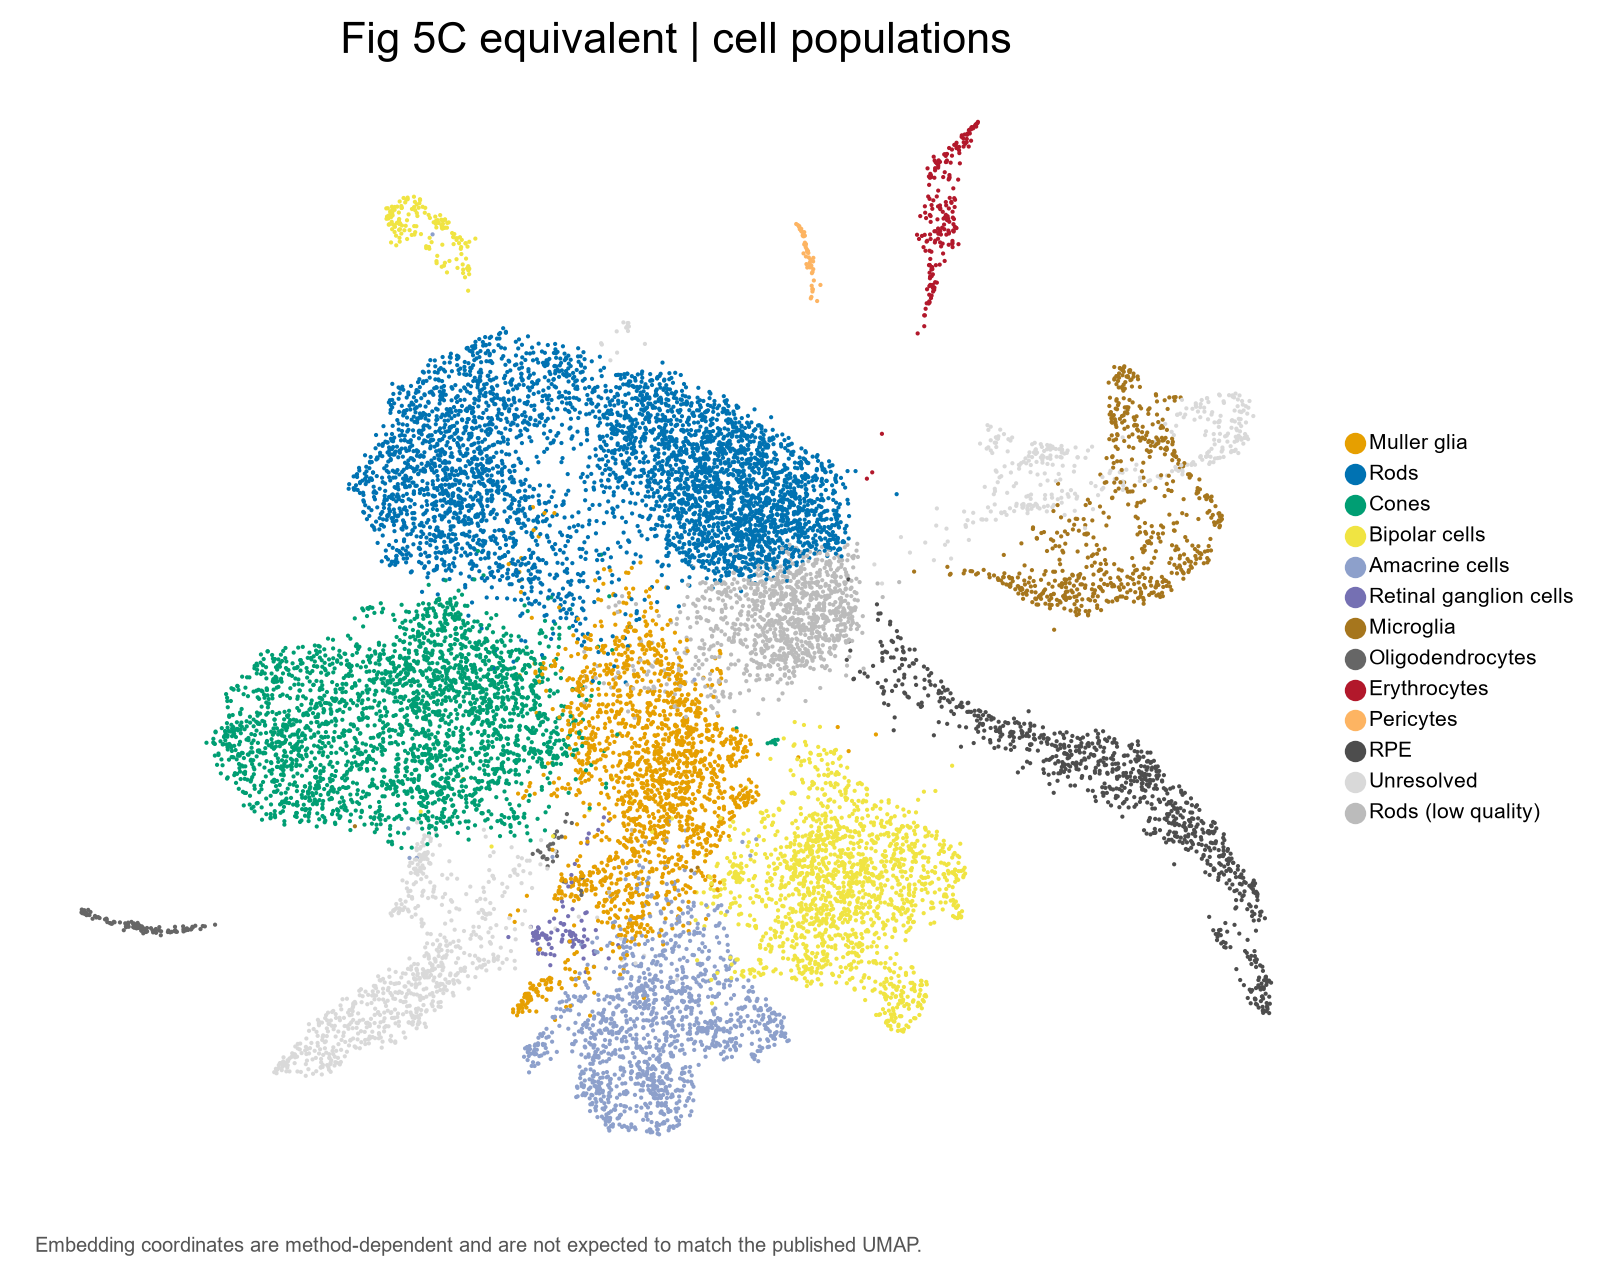

In [3]:
fig = pf.figure_5c_umap(adata)

Saved fig5D_marker_dotplot -> figures/paper_figure_reproduction/


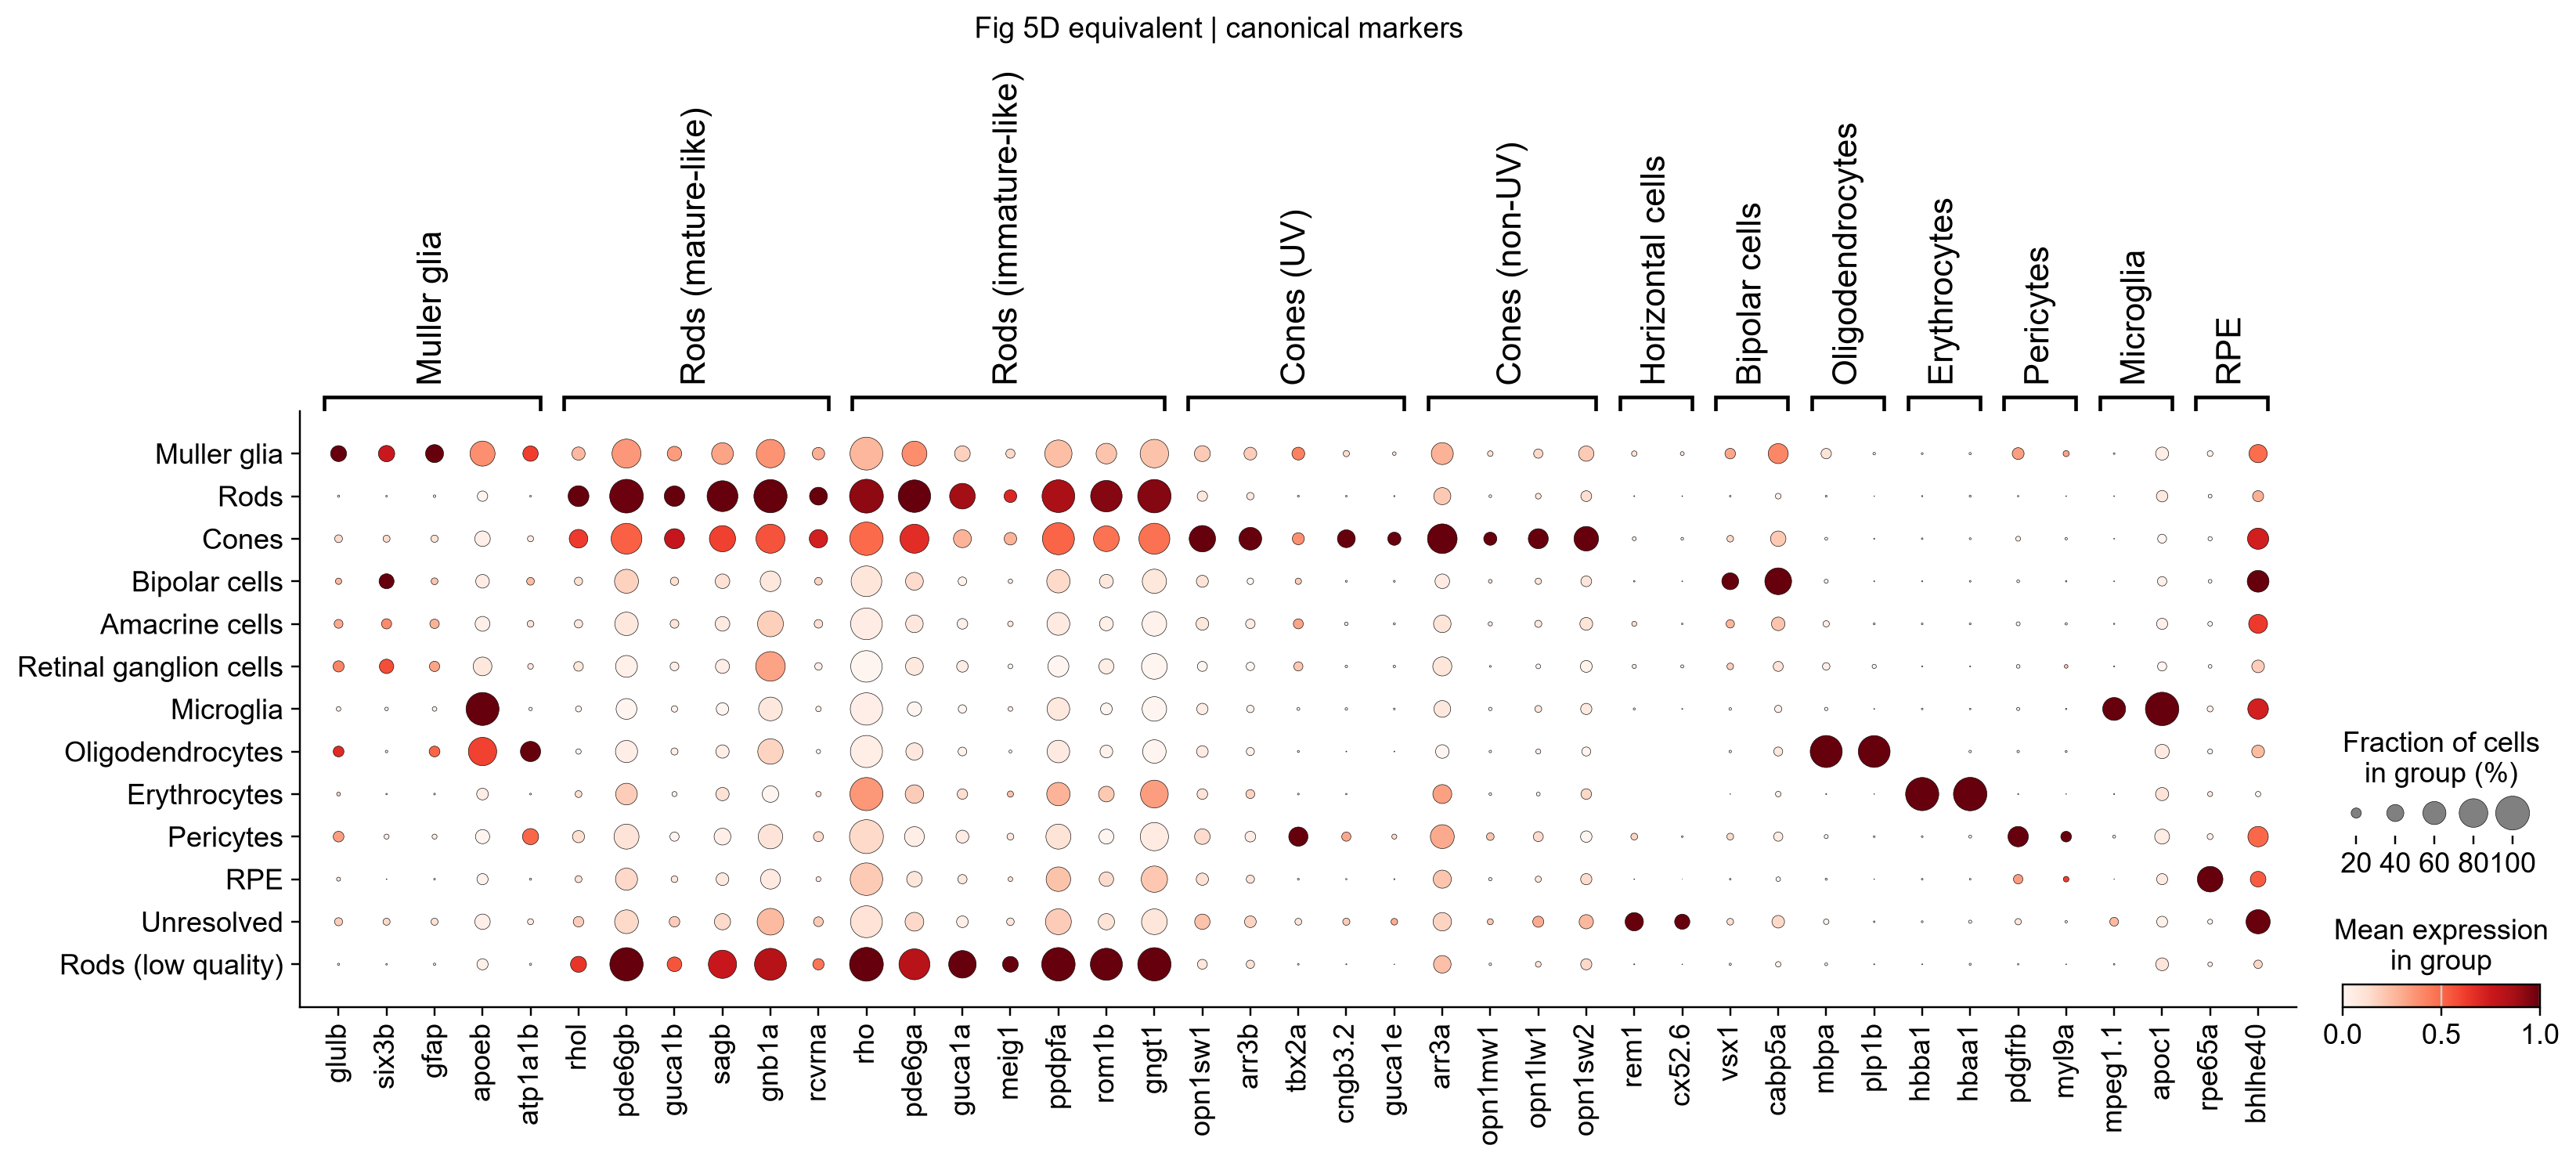

In [4]:
fig = pf.figure_5d_marker_dotplot(adata)

Saved fig5E_cluster_percentages -> figures/paper_figure_reproduction/


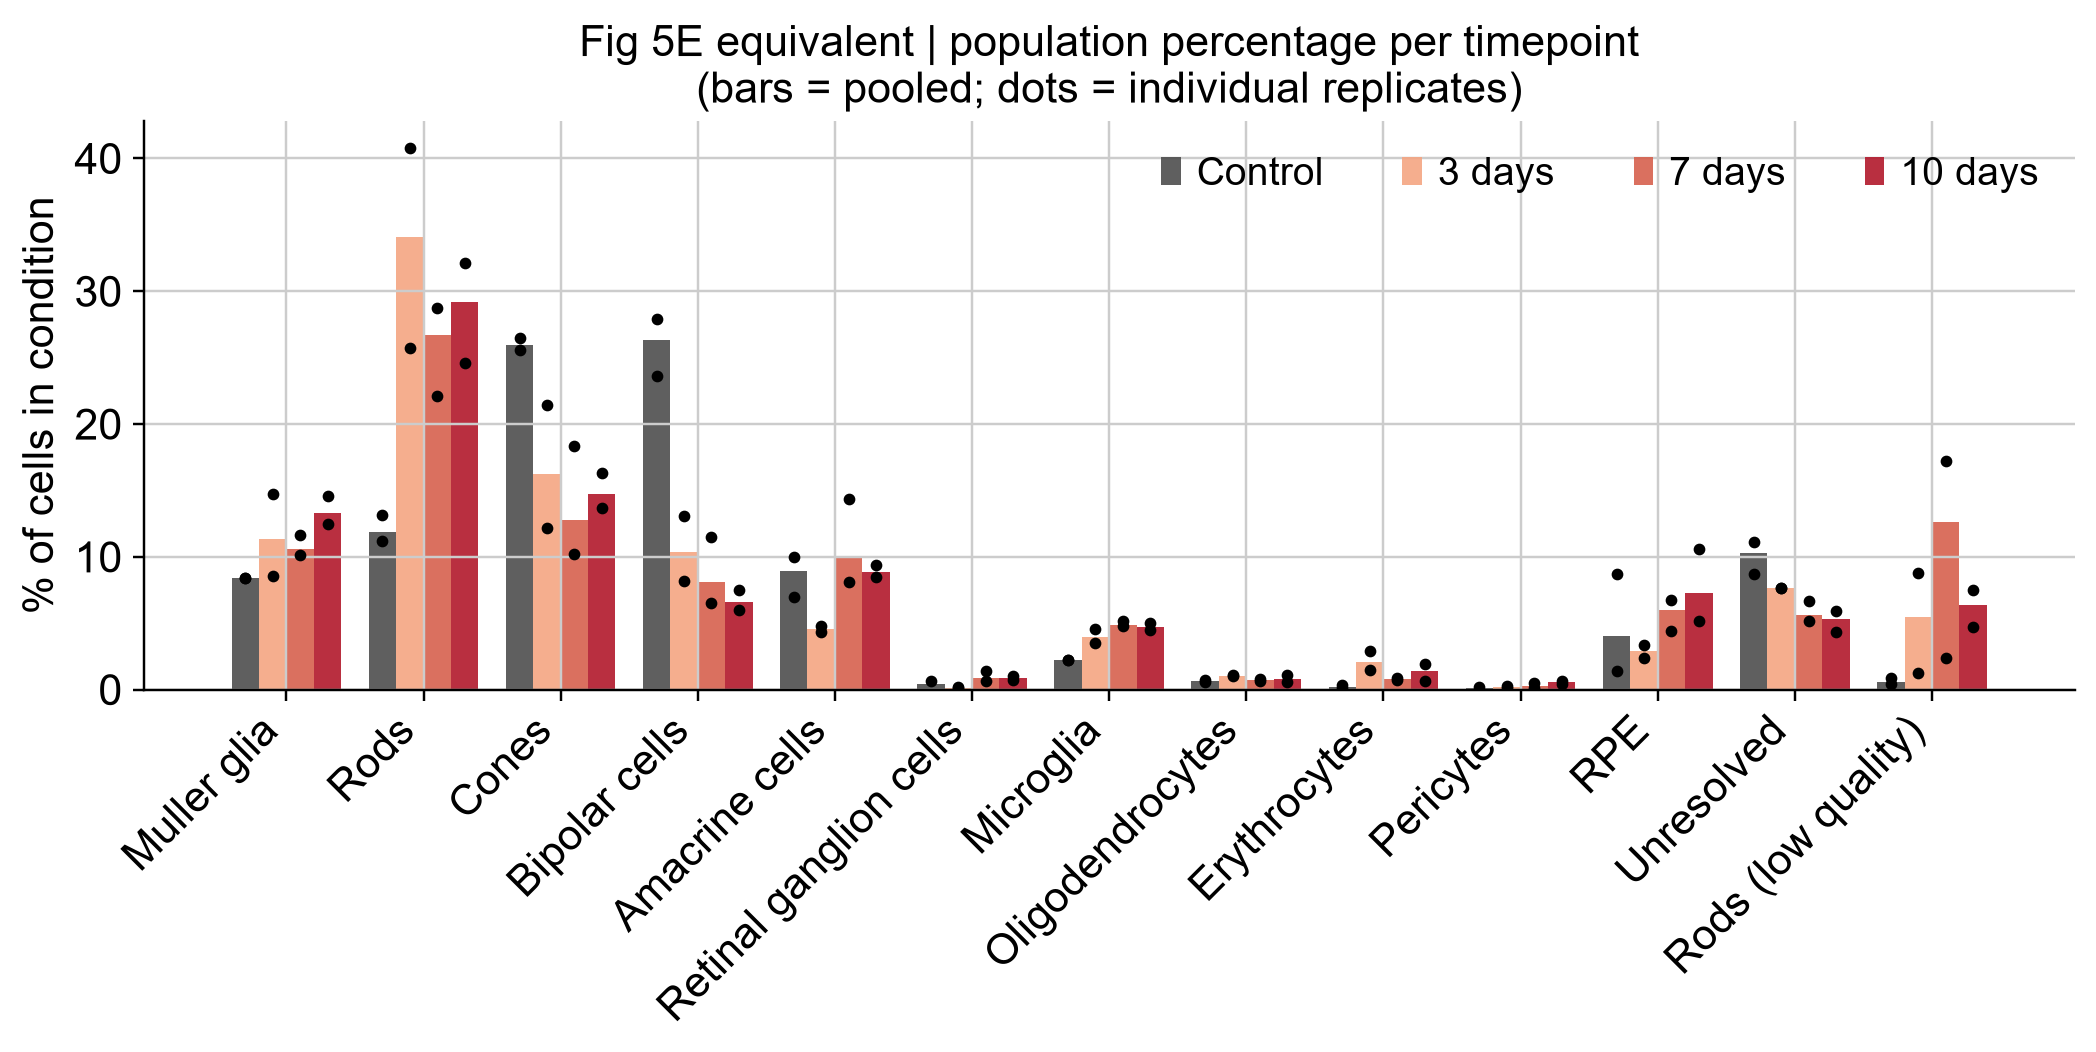

In [5]:
fig = pf.figure_5e_cluster_percentages(adata)


### Interpretation

Compare against the paper's Figure 5E, which reports rod cluster A expanding from
3.5% of control cells to 22 / 28 / 23% at 3 / 7 / 10 dpMNU. Our equivalent is the
overall rod increase. Remember the authors' own caveat: this reflects **capture
bias**, because rods detach more readily from a damaged outer nuclear layer.

Note also that our populations are annotated cell types, while theirs are numbered
clusters — so the panels are similar in construction but not in granularity.


## Figure 6 — rods

The decisive test of the paper's immature/mature rod split is the **paralog
inversion**: one cluster *rho* / *pde6ga* / *guca1a* high, the other *rhol* /
*pde6gb* / *guca1b* high. The function below prints an explicit verdict, because
this is a claim that should not be settled by squinting at a dot plot.

Saved fig6A_rod_umap -> figures/paper_figure_reproduction/


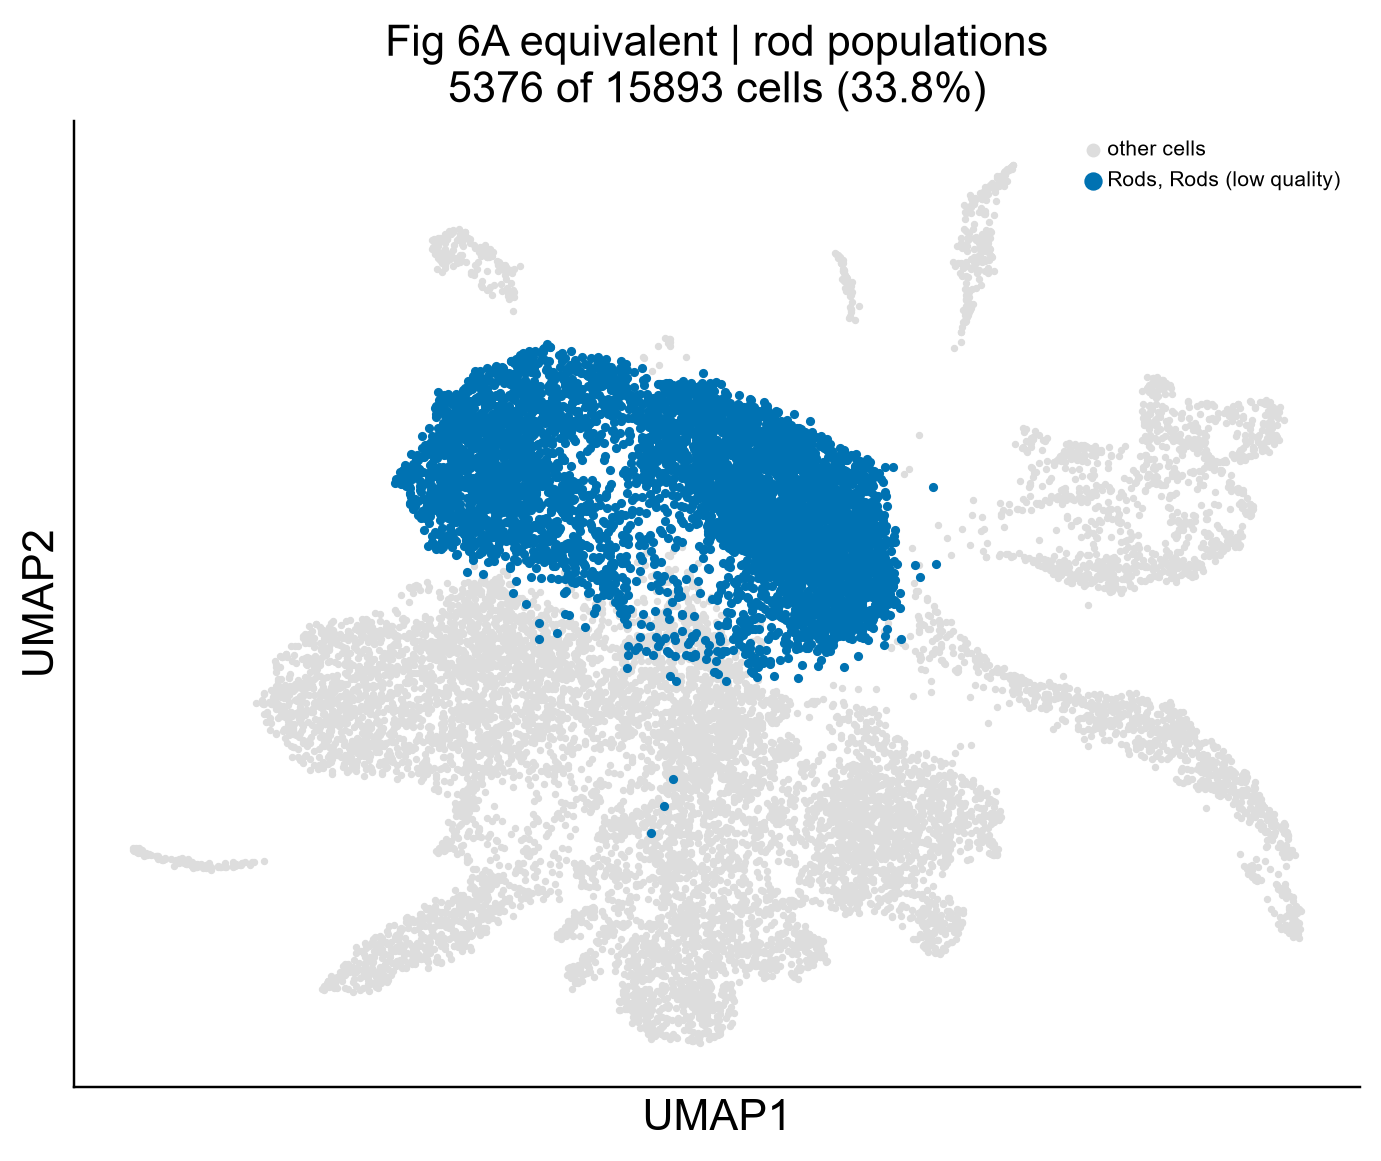

In [6]:
# Fig 6A equivalent: locate the rod populations in the whole atlas first.
fig = pf.figure_6a_rod_umap(adata)

In [7]:
rods, rod_evidence = egfp_analysis.rod_heterogeneity_evidence(adata)
display(rod_evidence)

Sub-analysis rebuilt from .raw: 22813 genes available (vs 2000 in the HVG-subset object).


C:\Users\Lenovo\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
D:\retina\project1_zebrafish_retina\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Subset re-clustered at resolution 0.3: 4 subclusters, 5376 cells.
[rod maturity panel] not in this dataset (1): ['prom1']


,n_cells,pct_ctrl,pct_3dp,pct_7dp,pct_10dp,rho,rhol,pde6ga,pde6gb,guca1a,...,meig1,ppdpfa,rom1b,gnat1,gngt1,nr2e3,sagb,rcvrna,gnb1a,crx
subcluster,,,,,,,,,,,,,,,,,,,,,
0,418,8.4,31.3,17.7,42.6,6.353,1.122,3.815,4.698,1.673,...,0.315,3.913,2.921,4.463,4.291,0.257,3.171,0.788,4.132,1.211
1,3149,1.1,27.4,31.9,39.6,7.631,1.271,3.928,5.717,2.908,...,1.078,5.753,4.170,5.175,5.305,0.128,2.948,0.673,4.183,0.627
2,1786,13.7,36.3,21.3,28.7,6.216,1.687,4.317,4.735,1.615,...,0.253,3.659,2.810,4.472,4.210,0.315,3.502,1.739,4.241,1.332
3,23,0.0,8.7,30.4,60.9,5.618,1.509,3.804,4.055,1.805,...,0.798,3.374,2.700,3.862,3.721,1.048,2.898,1.222,3.595,2.501


Saved fig6B_rod_paralog_dotplot -> figures/paper_figure_reproduction/

Paralog inversion test (mean log-normalised expression):
              rho   rhol  pde6ga  pde6gb  guca1a  guca1b
subcluster                                              
0           6.353  1.122   3.815   4.698   1.673   1.286
1           7.631  1.271   3.928   5.717   2.908   1.023
2           6.216  1.687   4.317   4.735   1.615   1.876
3           5.618  1.509   3.804   4.055   1.805   1.711
  rho > rhol in EVERY subcluster - no inversion
  pde6gb > pde6ga in EVERY subcluster - no inversion
  guca1a/guca1b SPLIT across subclusters - inversion present

An inversion requires the pairs to split in OPPOSITE directions across subclusters. If every pair points the same way in every subcluster, the paper's immature/mature rod distinction is not reproduced here, and that is the result to report.


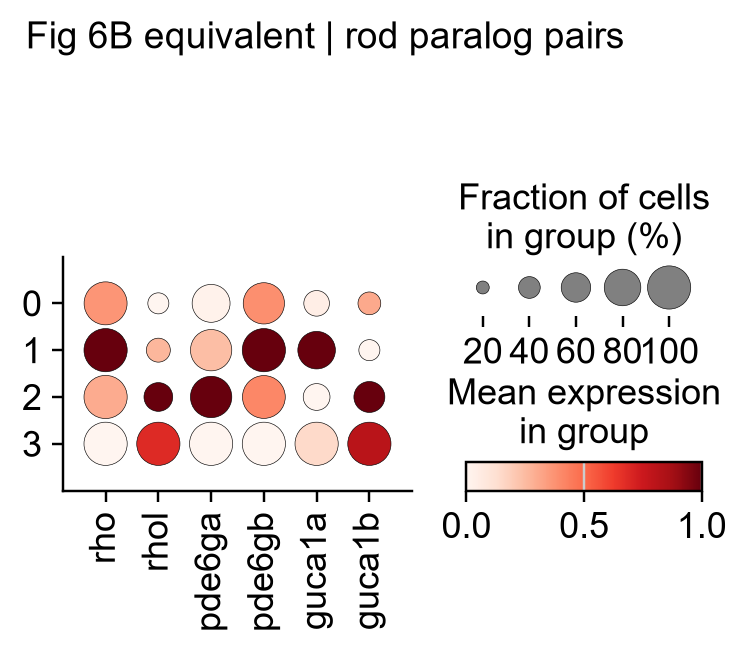

In [8]:
fig = pf.figure_6b_paralog_dotplot(rods)

Saved fig6E_rod_gene_heatmap -> figures/paper_figure_reproduction/


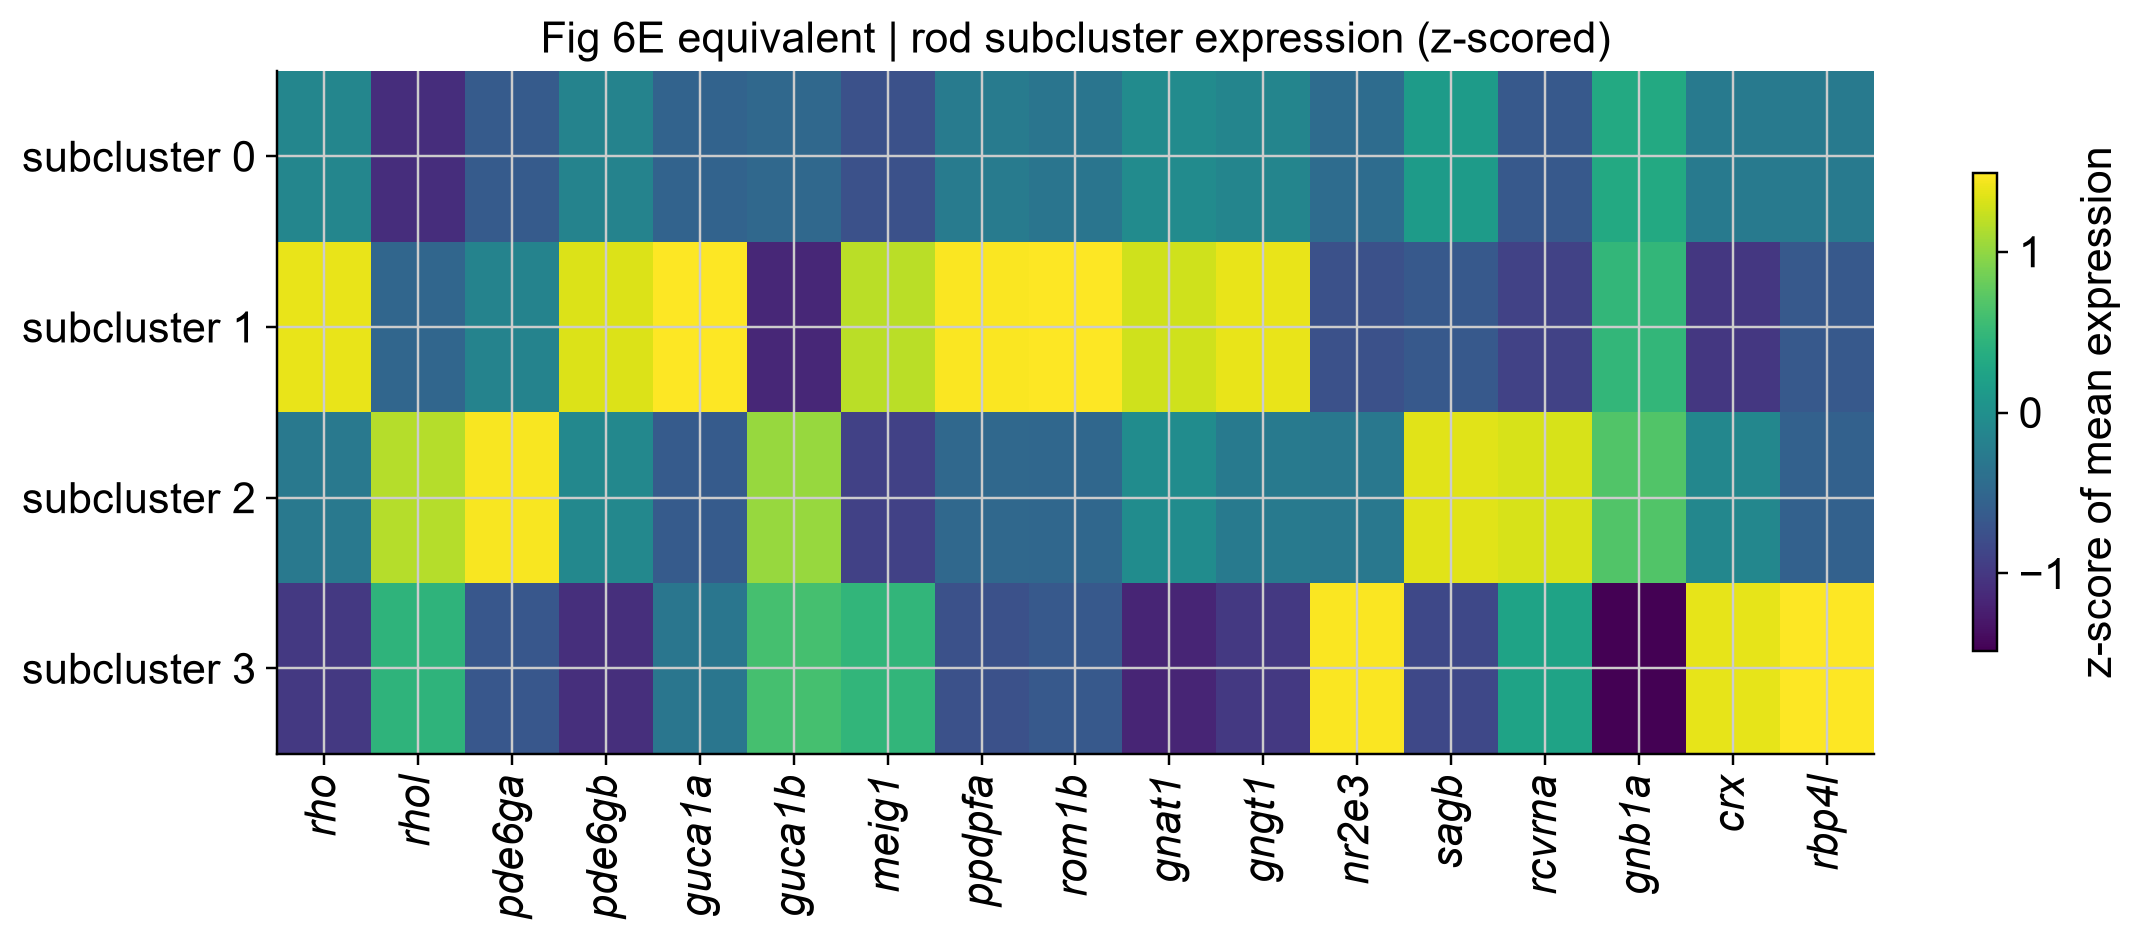

In [9]:
fig = pf.figure_6e_gene_heatmap(rods)


### Before interpreting rod subclusters: rule out sequencing depth

If one subcluster is higher on *every* gene rather than on a distinct programme,
the separation is depth, not biology. Check this before making any claim.

In [10]:
depth = rods.obs.groupby("subcluster", observed=True)[
    ["total_counts", "n_genes_by_counts", "pct_counts_mt"]].median().round(1)
display(depth)
print(
    "If median counts differ several-fold between subclusters and the expression "
    "differences run in the same direction for all genes, report the split as "
    "depth-driven rather than as a maturation state."
)

,total_counts,n_genes_by_counts,pct_counts_mt
subcluster,,,
0,659.0,361.5,4.8
1,875.0,317.0,10.1
2,888.0,510.5,2.6
3,232063.0,12154.0,5.4


If median counts differ several-fold between subclusters and the expression differences run in the same direction for all genes, report the split as depth-driven rather than as a maturation state.


Fig 6F equivalent | rods, 3 dpMNU vs control: 10 up, 14 down (|log2FC| >= 0.25, padj < 0.05)
  Reminder: these p-values come from a cell-level test with n = 2 replicates per condition, so they overstate significance. Treat the ranking as descriptive.
Saved fig6F_rod_volcano -> figures/paper_figure_reproduction/


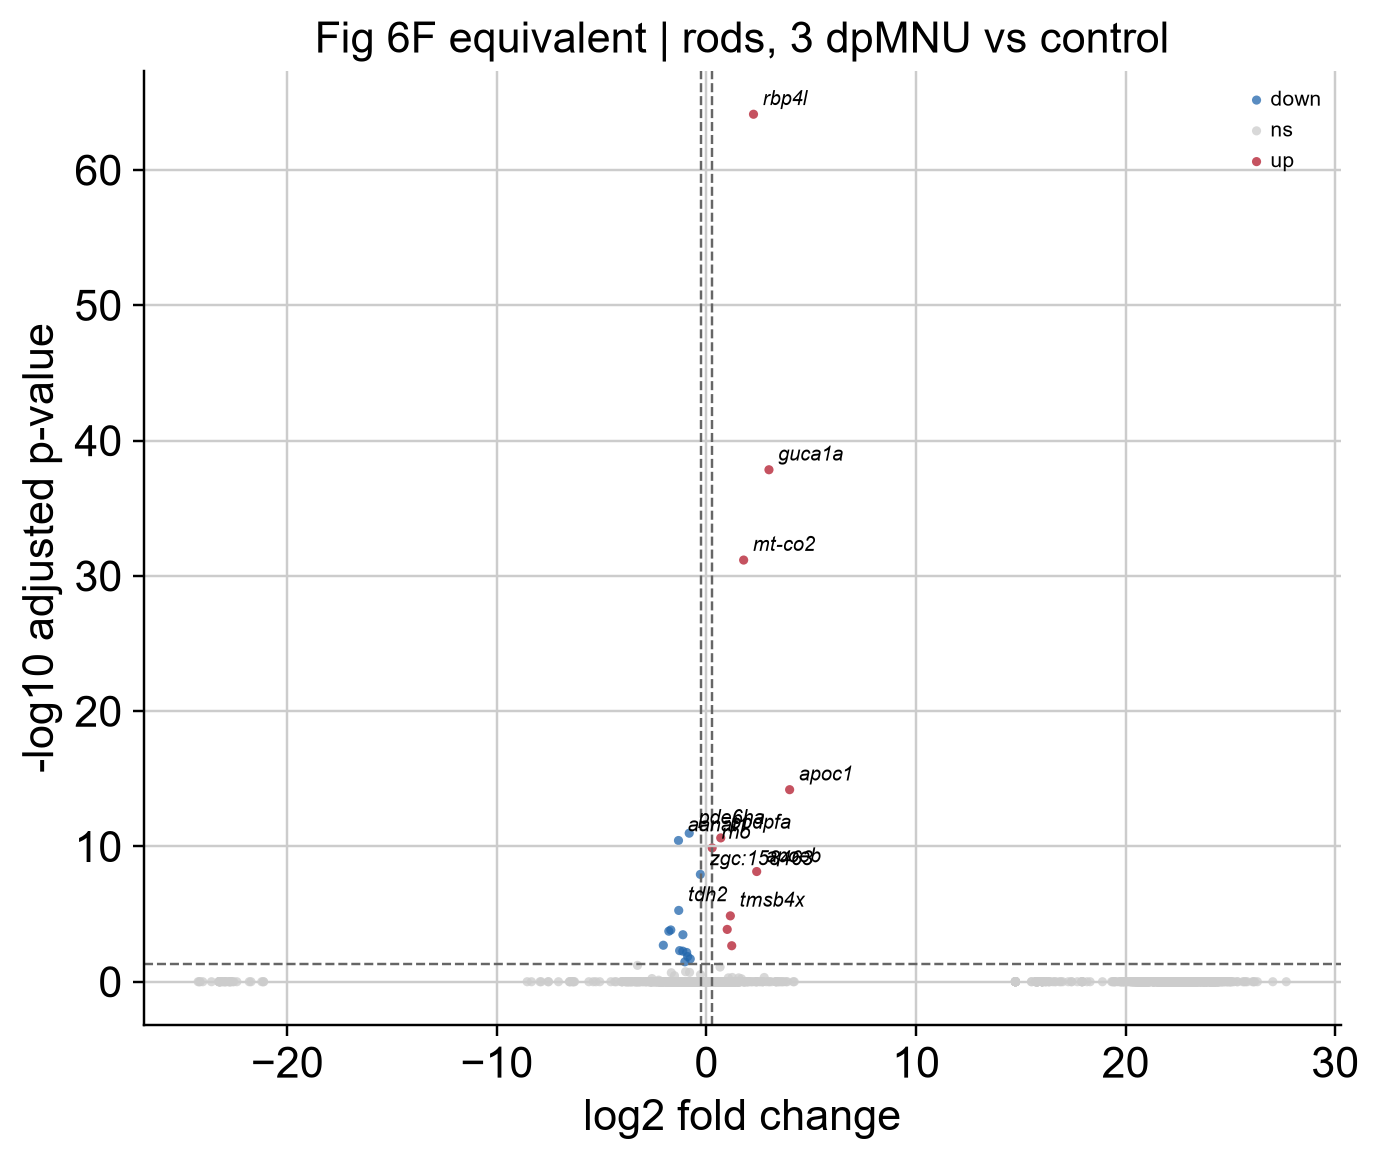

In [11]:
# Fig 6F equivalent: injured vs control within rods.
rod_types = [c for c in adata.obs["cell_type"].cat.categories if "rod" in str(c).lower()]
rod_de = egfp_analysis.injury_response_de(adata, cell_type=rod_types[0], condition="3dp")
if len(rod_de):
    fig = pf.volcano(rod_de, "Fig 6F equivalent | rods, 3 dpMNU vs control",
                     "fig6F_rod_volcano")

In [12]:
# Fig 6C/D equivalent: GO terms. Needs network access; skipped cleanly if offline.
if len(rod_de):
    up = rod_de[(rod_de["pval_adj"] < 0.05) & (rod_de["logfoldchange"] > 0.25)]["gene"].tolist()
    fig = pf.go_enrichment_bar(up, "Fig 6C/D equivalent | GO terms, rods up at 3 dpMNU",
                               "fig6CD_rod_go_terms")

[GO] Enrichment unavailable (ValueError: Invalid organism 'Fish'. Valid options are: c. elegans, caenorhabditis elegans, celegans, d. melanogaster, d. rerio, danio rerio, drosophila, drosophila melanogaster, enrichr, fish, fly, h. sapiens, homo sapiens, hs, hsapiens, human, m. musculus, mm, mouse, mus musculus, nematode, s. cerevisiae, saccharomyces, saccharomyces cerevisiae, worm, yeast, zebrafish). Report GO analysis as not performed rather than omitting silently.



## Figure 7 — cones

The paper separates a UV cone cluster (*opn1sw1*-high, *arr3b*+, *arr3a*-negative)
from non-UV cones (*arr3a*+).

Saved fig7A_cone_umap -> figures/paper_figure_reproduction/


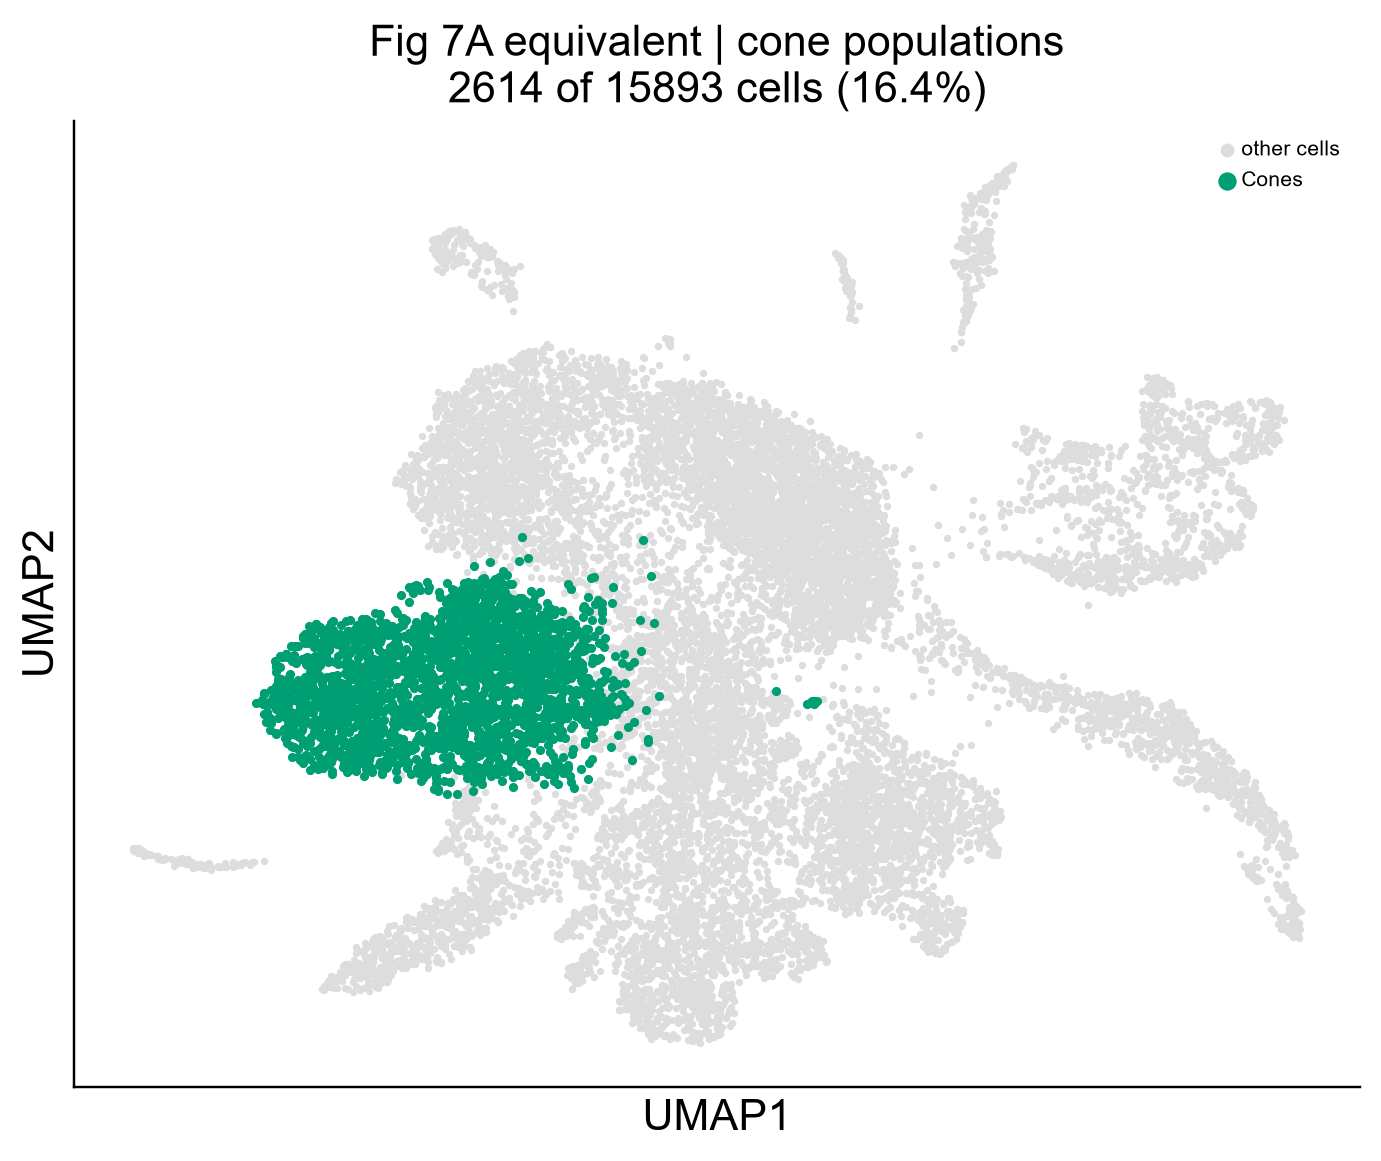

In [13]:
# Fig 7A equivalent: locate the cone populations in the whole atlas.
fig = pf.figure_7a_cone_umap(adata)

In [14]:
cones, cone_evidence = egfp_analysis.cone_subtype_evidence(adata)
display(cone_evidence)

Sub-analysis rebuilt from .raw: 22813 genes available (vs 2000 in the HVG-subset object).


C:\Users\Lenovo\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Subset re-clustered at resolution 0.3: 7 subclusters, 2614 cells.


,n_cells,pct_ctrl,pct_3dp,pct_7dp,pct_10dp,opn1sw1,opn1sw2,opn1mw1,opn1mw2,opn1lw1,opn1lw2,arr3a,arr3b,tbx2a,cngb3.2,guca1e,gnat2,pde6c
subcluster,,,,,,,,,,,,,,,,,,
0,364,22.3,24.2,25.8,27.7,2.873,2.713,1.294,2.561,1.736,1.931,2.587,1.077,0.171,0.408,0.397,3.615,2.761
1,752,25.7,23.9,26.1,24.3,2.950,2.270,0.632,2.444,1.096,1.152,3.289,1.601,0.210,0.295,0.180,3.432,3.100
2,408,2.5,29.4,20.3,47.8,2.677,2.234,0.674,2.202,1.627,1.413,3.431,2.075,0.590,1.055,0.387,3.682,3.228
3,406,1.2,32.5,9.9,56.4,0.703,1.081,0.410,2.144,1.504,1.017,3.910,0.833,0.103,1.103,0.230,3.864,3.632
4,285,38.2,37.2,6.3,18.2,5.068,1.270,0.146,0.428,0.211,0.296,0.830,3.344,1.088,1.770,1.484,4.026,3.112
5,184,25.5,26.1,23.9,24.5,2.644,2.064,0.654,1.739,1.090,1.039,3.295,1.704,0.370,0.362,0.177,2.904,2.826
6,215,96.3,1.4,0.5,1.9,1.854,2.234,1.736,2.955,2.321,2.439,2.428,0.783,0.269,0.950,1.161,3.564,3.032


Saved fig7B_opsin_heatmap -> figures/paper_figure_reproduction/

Highest opn1sw1 (UV opsin): subcluster 4
            opn1sw1  opn1sw2  opn1mw1  opn1mw2  opn1mw3  opn1mw4  opn1lw1  opn1lw2
subcluster                                                                        
0             2.873    2.713    1.294    2.561    1.219    0.746    1.736    1.931
1             2.950    2.270    0.632    2.444    1.082    0.333    1.096    1.152
2             2.677    2.234    0.674    2.202    1.057    0.538    1.627    1.413
3             0.703    1.081    0.410    2.144    0.972    0.654    1.504    1.017
4             5.068    1.270    0.146    0.428    0.154    0.088    0.211    0.296
5             2.644    2.064    0.654    1.739    1.021    1.160    1.090    1.039
6             1.854    2.234    1.736    2.955    0.872    0.494    2.321    2.439

The paper separates a UV cone cluster (opn1sw1-high, arr3b+, arr3a-) from non-UV cones (arr3a+). Check the arr3 paralogs in Fig 7D before concludi

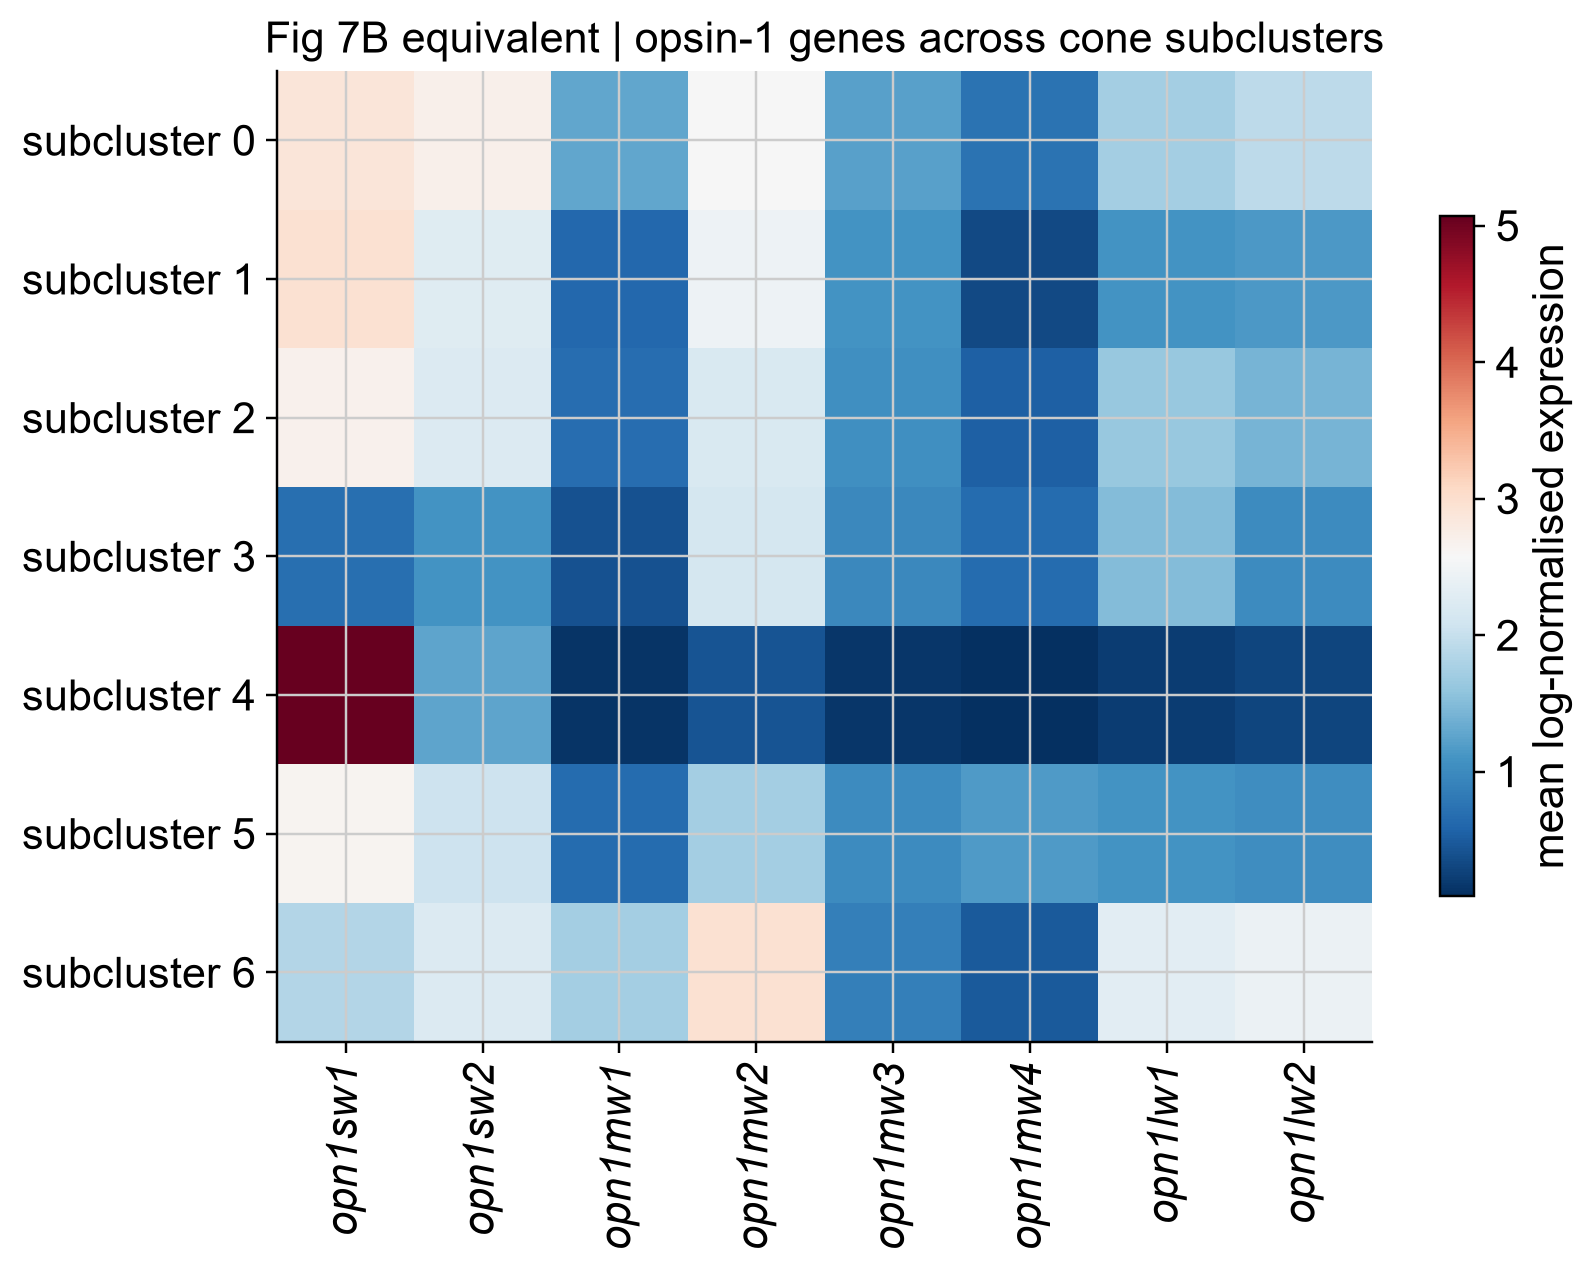

In [15]:
fig = pf.figure_7b_opsin_heatmap(cones)

Saved fig7D_cone_gene_heatmap -> figures/paper_figure_reproduction/

arr3 paralog usage (the paper reports a near-inverse pattern):
            arr3a  arr3b
subcluster              
0           2.587  1.077
1           3.289  1.601
2           3.431  2.075
3           3.910  0.833
4           0.830  3.344
5           3.295  1.704
6           2.428  0.783


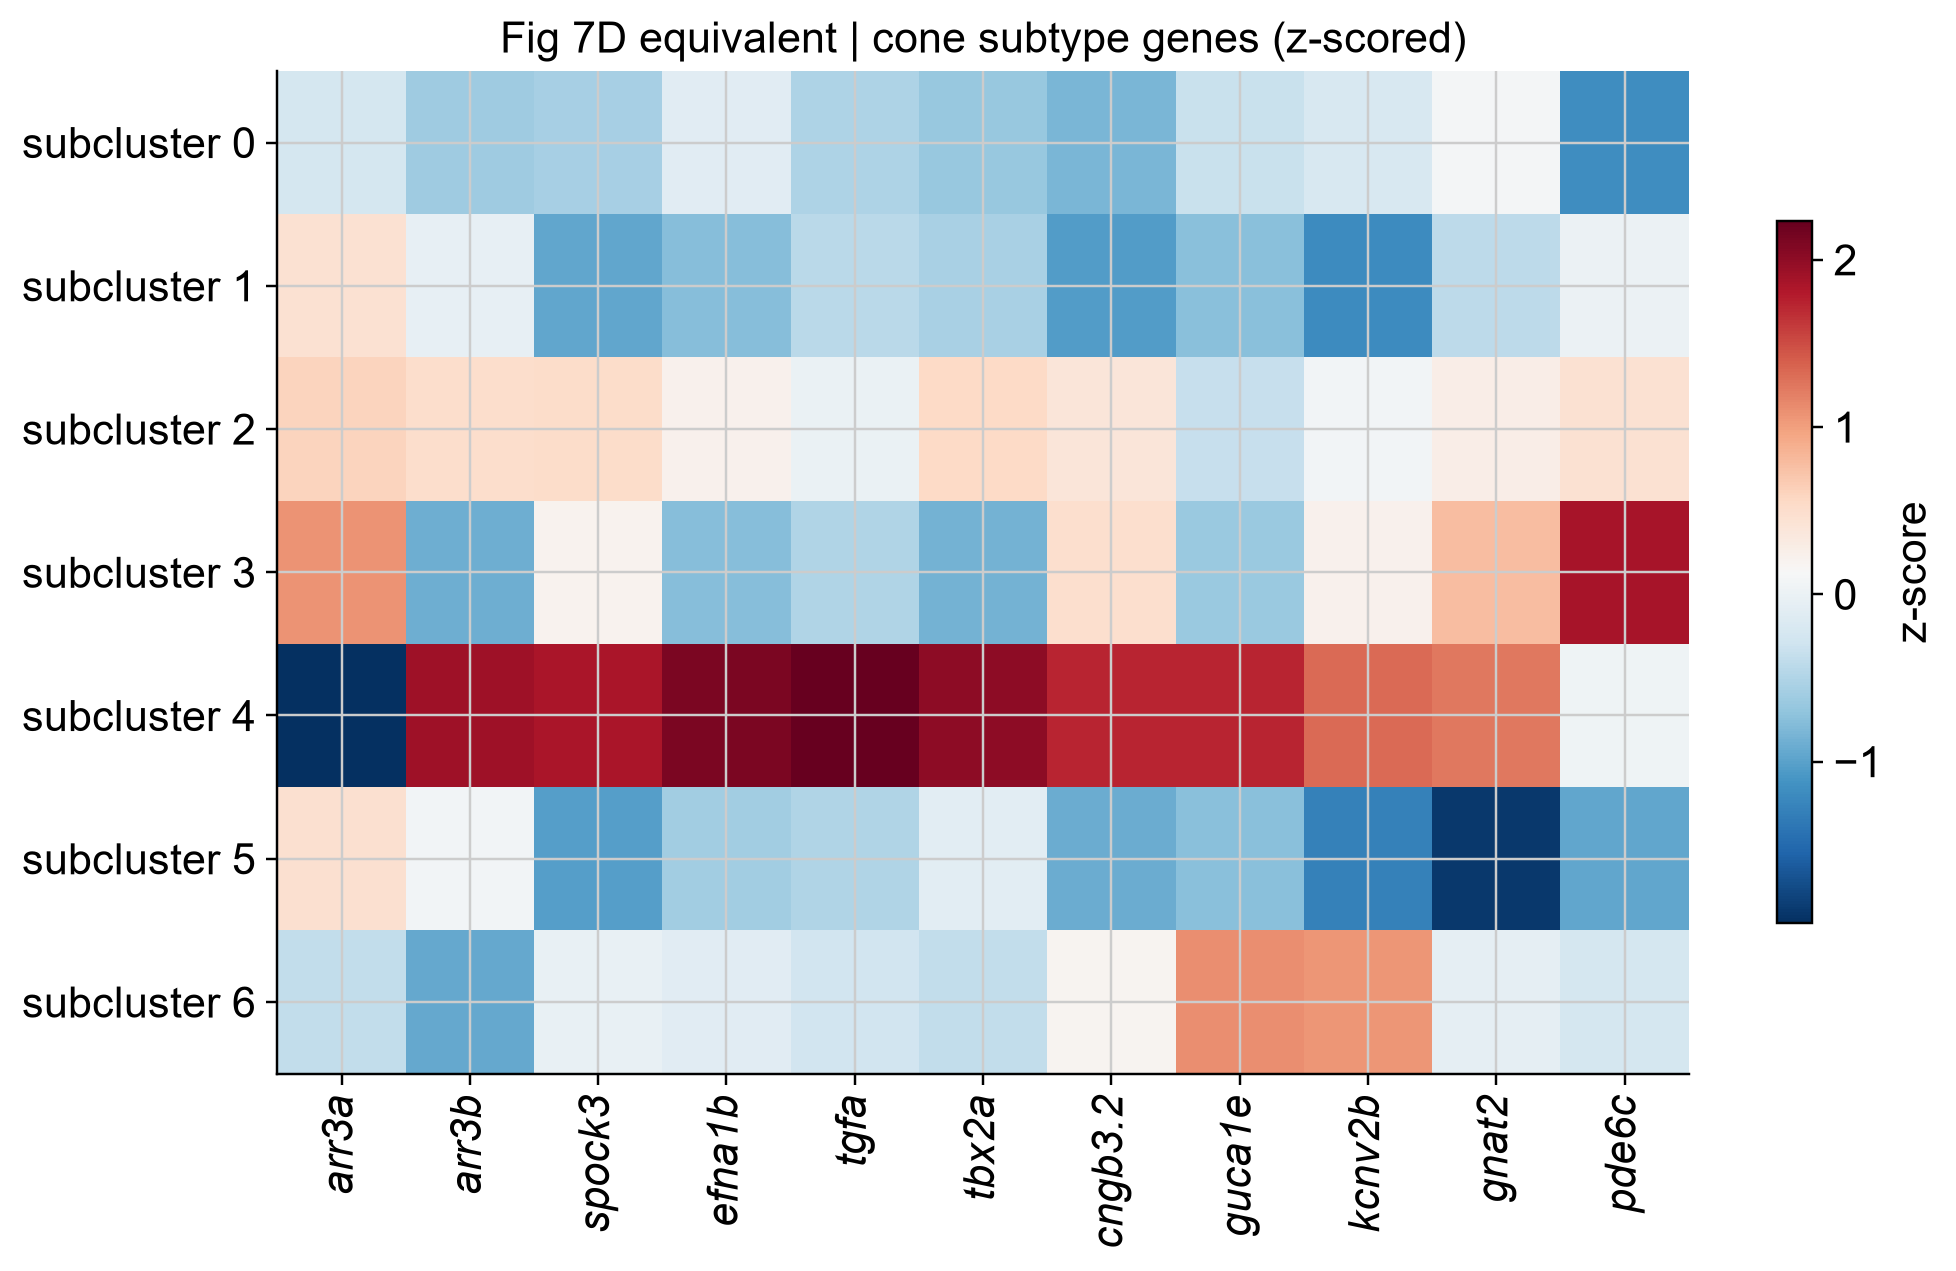

In [16]:
fig = pf.figure_7d_cone_heatmap(cones)

Fig 7E equivalent | cones, 3 dpMNU vs control: 50 up, 10 down (|log2FC| >= 0.25, padj < 0.05)
  Reminder: these p-values come from a cell-level test with n = 2 replicates per condition, so they overstate significance. Treat the ranking as descriptive.
Saved fig7E_cone_volcano -> figures/paper_figure_reproduction/
[GO] Enrichment unavailable (ValueError: Invalid organism 'Fish'. Valid options are: c. elegans, caenorhabditis elegans, celegans, d. melanogaster, d. rerio, danio rerio, drosophila, drosophila melanogaster, enrichr, fish, fly, h. sapiens, homo sapiens, hs, hsapiens, human, m. musculus, mm, mouse, mus musculus, nematode, s. cerevisiae, saccharomyces, saccharomyces cerevisiae, worm, yeast, zebrafish). Report GO analysis as not performed rather than omitting silently.


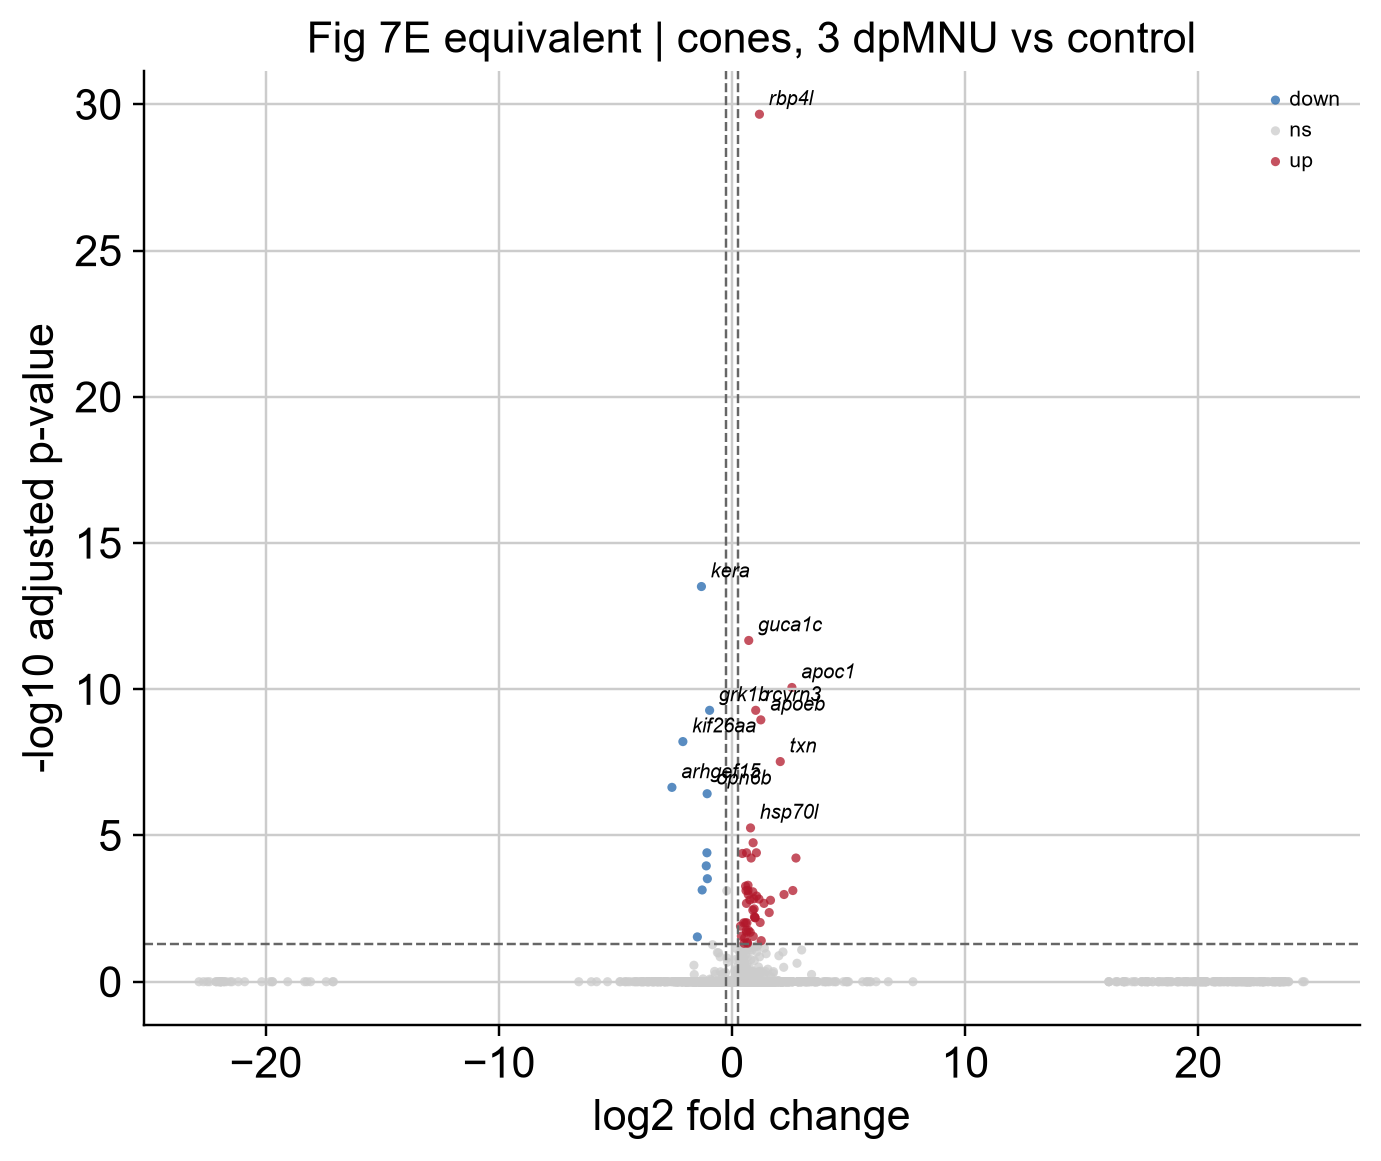

In [17]:
cone_types = [c for c in adata.obs["cell_type"].cat.categories if "cone" in str(c).lower()]
cone_de = egfp_analysis.injury_response_de(adata, cell_type=cone_types[0], condition="3dp")
if len(cone_de):
    fig = pf.volcano(cone_de, "Fig 7E equivalent | cones, 3 dpMNU vs control",
                     "fig7E_cone_volcano")
    up = cone_de[(cone_de["pval_adj"] < 0.05) & (cone_de["logfoldchange"] > 0.25)]["gene"].tolist()
    fig = pf.go_enrichment_bar(up, "Fig 7F equivalent | GO terms, cones up at 3 dpMNU",
                               "fig7F_cone_go_terms")


## Figure 8 — the careg:EGFP reporter

This is the paper's central scRNA-seq claim and our strongest reproduction.

Saved fig8A_egfp_umap_by_condition -> figures/paper_figure_reproduction/


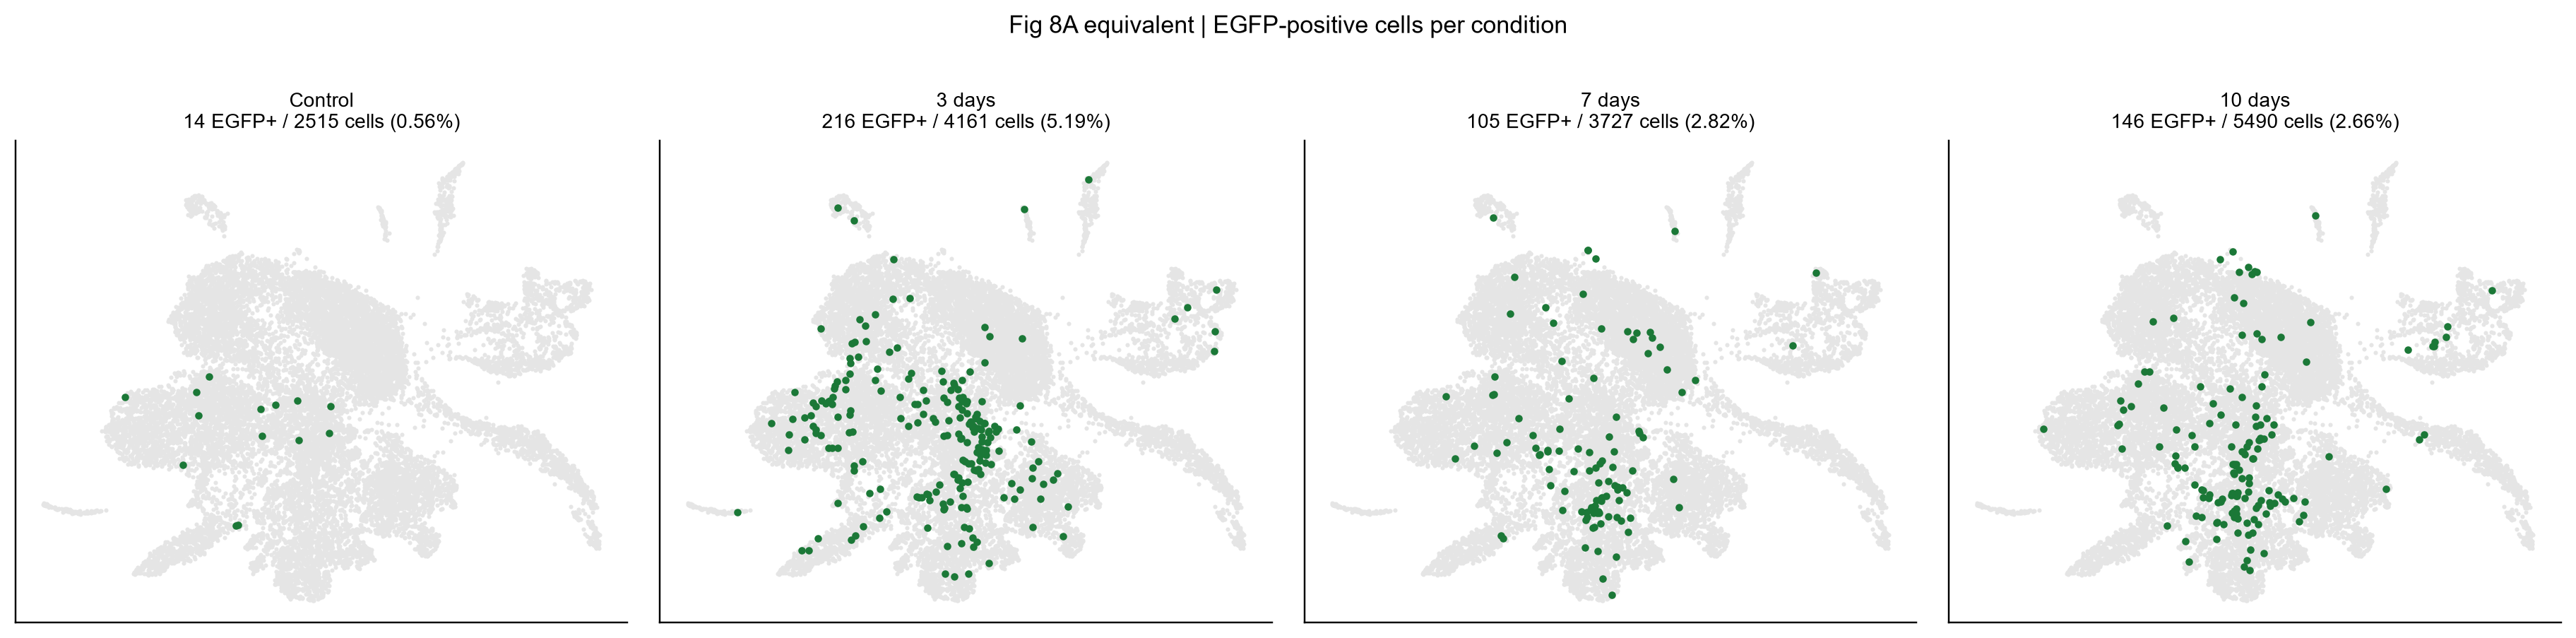

In [18]:
fig = pf.figure_8a_egfp_umap(adata)

Saved fig8B_egfp_counts -> figures/paper_figure_reproduction/

Paper values for comparison: 0.54% (ctrl), 5.40% (3dp), 2.64% (7dp), 2.66% (10dp).


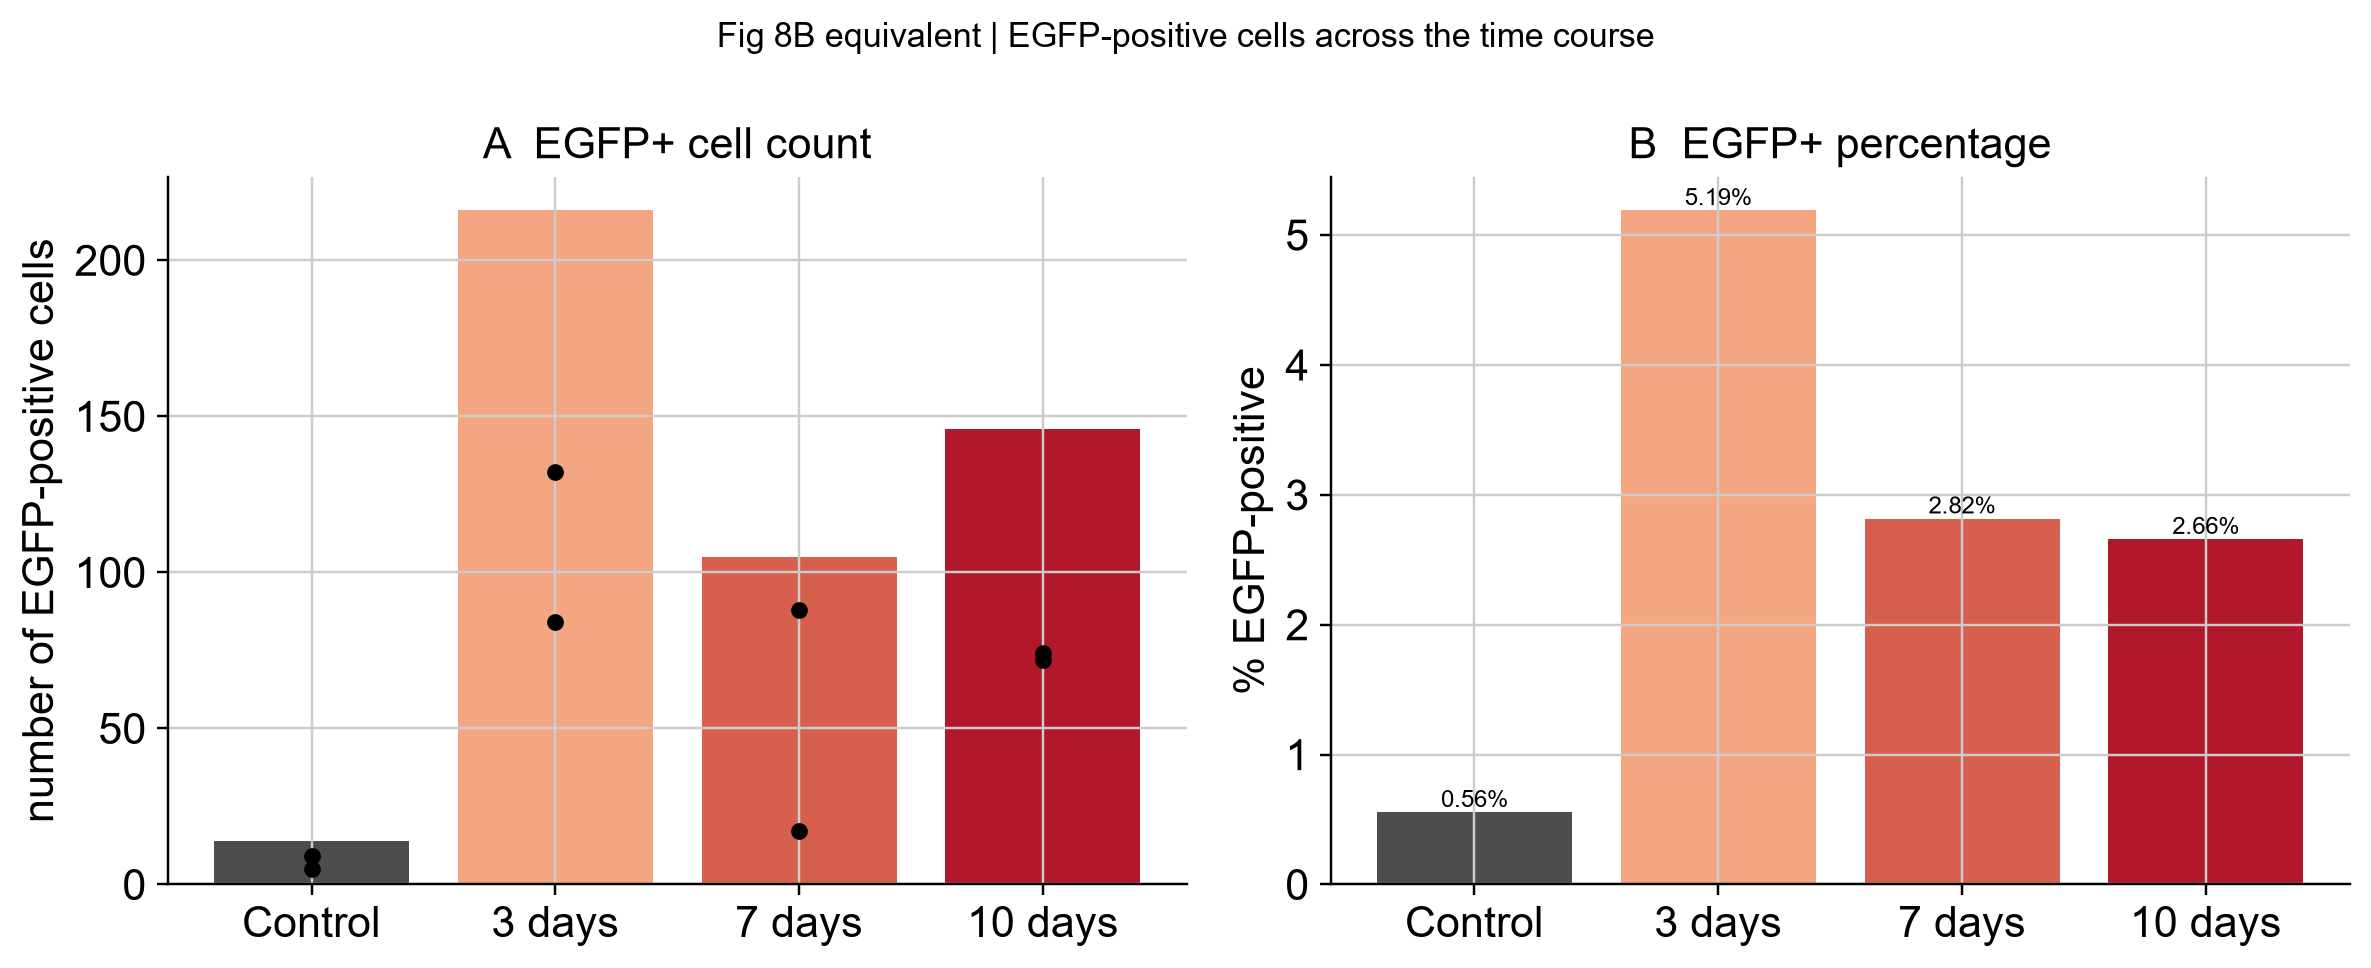

In [19]:
fig = pf.figure_8b_egfp_counts(adata)

D:\retina\project1_zebrafish_retina\scripts\paper_figures.py:421: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(df.index.astype(str), rotation=45, ha="right")


Saved fig8C_egfp_per_cluster -> figures/paper_figure_reproduction/

Paper: EGFP transcripts in nearly 10% of Muller glia, an outstanding proportion among other cell types.


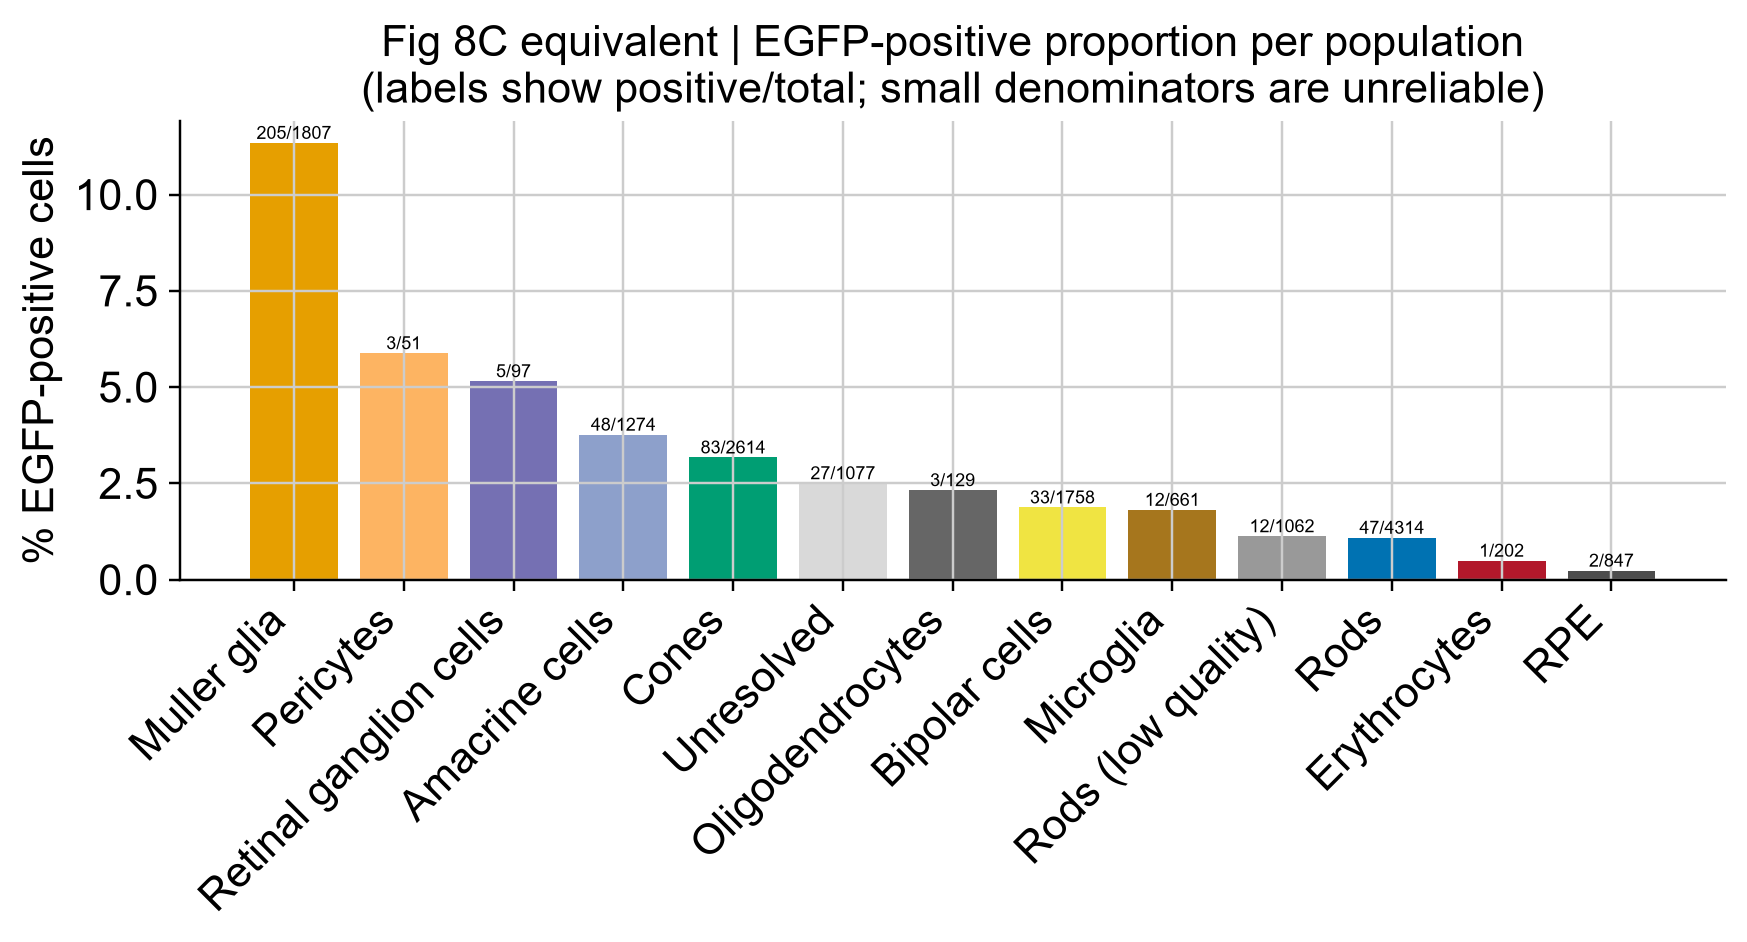

In [20]:
fig = pf.figure_8c_egfp_per_cluster(adata)

Saved fig8D_muller_glia_umap -> figures/paper_figure_reproduction/


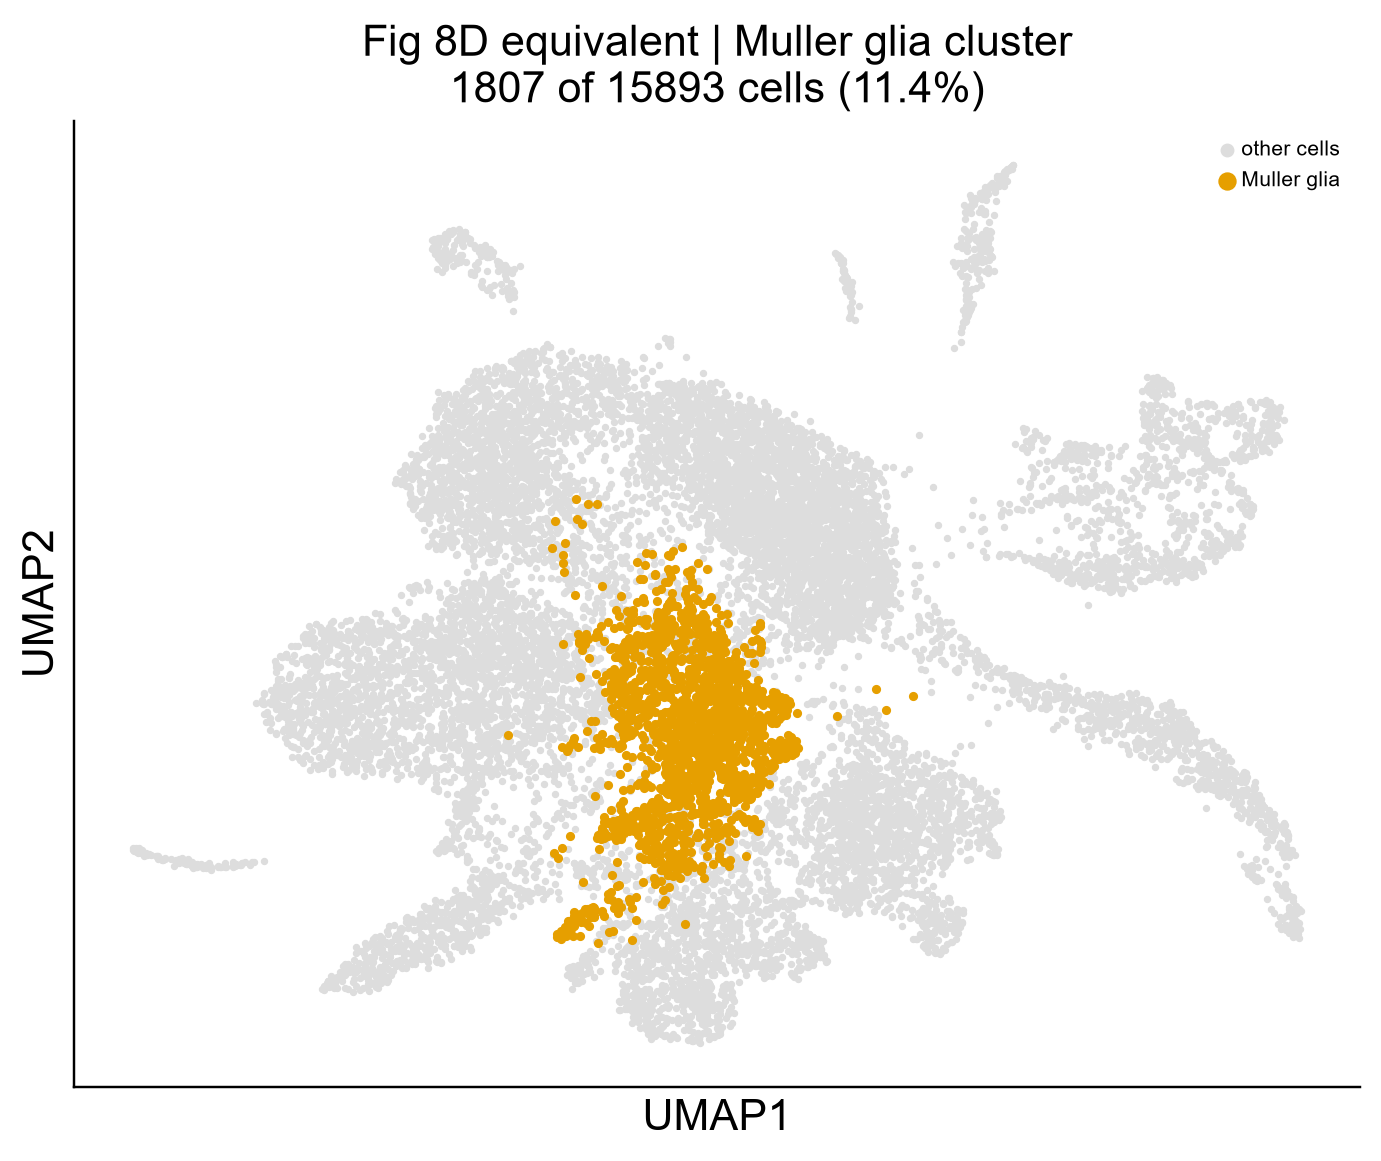

In [21]:
# Fig 8D equivalent: the Muller glia cluster located in the integrated data.
fig = pf.figure_8d_mg_umap(adata)

Wrote tables\egfp_pos_vs_neg_muller_glia.csv  (2000 rows)
Saved fig8E_egfp_mg_heatmap -> figures/paper_figure_reproduction/

Paper: 42 genes upregulated in careg:EGFP-positive Muller glia, including six3b, glulb, gfap, apoeb, mdka, crabp1a, id1, mmp9.


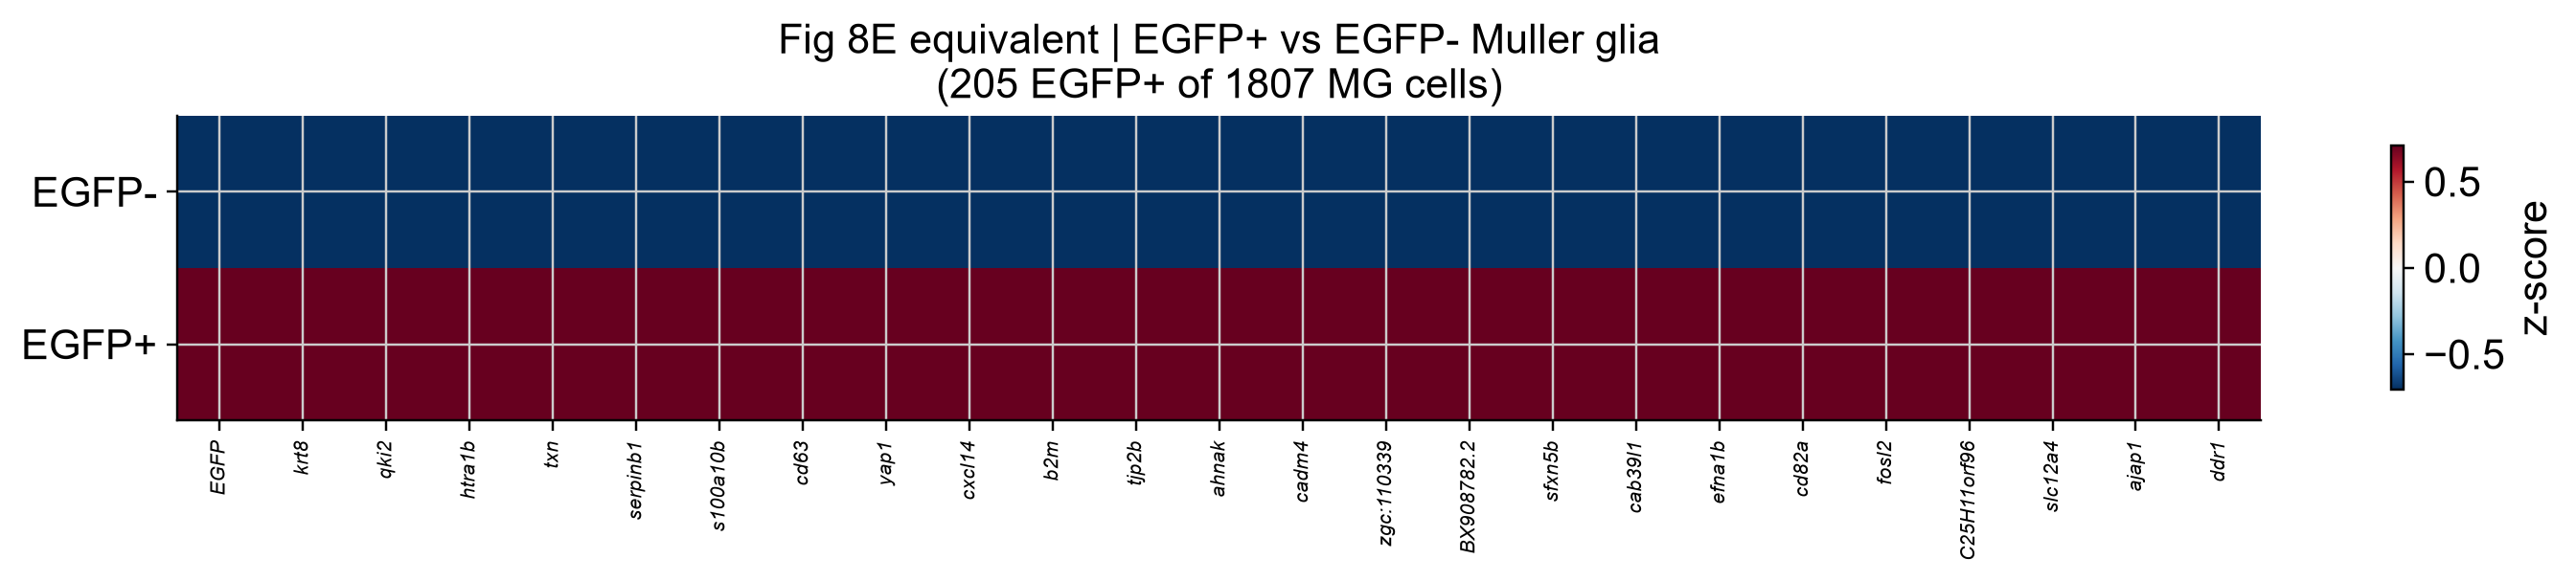

In [22]:
# Fig 8E equivalent: EGFP+ vs EGFP- Muller glia.
mg_types = [c for c in adata.obs["cell_type"].cat.categories if "muller" in str(c).lower()]
frames = [egfp_analysis.egfp_de_within_group(adata, ct) for ct in mg_types]
frames = [f for f in frames if len(f)]
if frames:
    mg_de = pd.concat(frames, ignore_index=True)
    io_utils.save_table(mg_de, "egfp_pos_vs_neg_muller_glia.csv")
    fig = pf.figure_8e_egfp_mg_heatmap(adata, mg_de)
else:
    print(
        "The EGFP+/- Muller glia comparison was underpowered. Report that plainly: "
        "the paper had more cells, and an underpowered negative is not the same as "
        "a failure to replicate their 42-gene signature."
    )


## Summary table for the report

In [23]:
summary = pd.DataFrame([
    {"paper_figure": "Fig 5C", "content": "UMAP atlas",
     "status": "content comparable; coordinates not reproducible by construction"},
    {"paper_figure": "Fig 5D", "content": "canonical marker dot plot", "status": "reproduced"},
    {"paper_figure": "Fig 5E", "content": "population % per timepoint", "status": "reproduced"},
    {"paper_figure": "Fig 6B", "content": "rod paralog inversion",
     "status": "see printed verdict above"},
    {"paper_figure": "Fig 6C/D", "content": "GO terms",
     "status": "Enrichr, not topGO - different background and gene sets"},
    {"paper_figure": "Fig 6E", "content": "rod gene heatmap", "status": "reproduced"},
    {"paper_figure": "Fig 6F", "content": "rod volcano", "status": "reproduced"},
    {"paper_figure": "Fig 7B", "content": "opsin heatmap", "status": "reproduced"},
    {"paper_figure": "Fig 7D", "content": "cone gene heatmap", "status": "reproduced"},
    {"paper_figure": "Fig 7E/F", "content": "cone volcano, GO", "status": "reproduced"},
    {"paper_figure": "Fig 8A", "content": "EGFP+ cells on UMAP", "status": "reproduced"},
    {"paper_figure": "Fig 8B", "content": "EGFP+ counts per timepoint",
     "status": "reproduced; values match within 0.2 percentage points"},
    {"paper_figure": "Fig 8C", "content": "EGFP+ % per population", "status": "reproduced"},
    {"paper_figure": "Fig 8E", "content": "EGFP+/- MG heatmap", "status": "see cell above"},
    {"paper_figure": "Fig 6A", "content": "rod clusters highlighted on UMAP", "status": "reproduced"},
    {"paper_figure": "Fig 7A", "content": "cone clusters highlighted on UMAP", "status": "reproduced"},
    {"paper_figure": "Fig 8D", "content": "Muller glia cluster highlighted", "status": "reproduced"},
    {"paper_figure": "Fig 5A", "content": "experimental design schematic",
     "status": "not data - a drawing; redraw for the Introduction if wanted"},
    {"paper_figure": "Fig 5B", "content": "immunofluorescence, inactivated-MNU control",
     "status": "no scRNA-seq counterpart"},
    {"paper_figure": "Fig 7C", "content": "colour scale for 7B/7D",
     "status": "absorbed - each heatmap carries its own colorbar"},
    {"paper_figure": "Fig 1-4, 9-11", "content": "immunofluorescence, TOR, rapamycin",
     "status": "no scRNA-seq counterpart - not attempted"},
])
io_utils.save_table(summary, "paper_figure_reproduction_status.csv")
display(summary)

Wrote tables\paper_figure_reproduction_status.csv  (21 rows)


,paper_figure,content,status
0,Fig 5C,UMAP atlas,content comparable; coordinates not reproducib...
1,Fig 5D,canonical marker dot plot,reproduced
2,Fig 5E,population % per timepoint,reproduced
3,Fig 6B,rod paralog inversion,see printed verdict above
4,Fig 6C/D,GO terms,"Enrichr, not topGO - different background and ..."
5,Fig 6E,rod gene heatmap,reproduced
6,Fig 6F,rod volcano,reproduced
7,Fig 7B,opsin heatmap,reproduced
8,Fig 7D,cone gene heatmap,reproduced
9,Fig 7E/F,"cone volcano, GO",reproduced



### What to check before continuing

- [ ] Every panel exists as PNG **and** PDF in `figures/paper_figure_reproduction/`.
- [ ] The paralog verdict printed for Fig 6B is recorded — reproduced or not.
- [ ] Rod subcluster depth checked, so any split is not merely sequencing depth.
- [ ] GO status recorded: performed via Enrichr, or reported as not performed.
- [ ] Fig 8E either drawn or reported as underpowered.
- [ ] The report states that UMAP coordinates are not reproducible by construction.